# Exploratory Data Analysis: Steam's Highest-Revenue Games of 2024

**Holon Institute of Technology (HIT) — Faculty of Computer Science**

| | |
|---|---|
| **Course** | Introduction to Data Science |
| **Assignment** | 1 — Exploratory Data Analysis (EDA) |
| **Student name** | Sean Mazon |
| **ID number** | 212234660 |
| **Lecturer** | Dr. Ori Itai |
| **Teaching assistant** | Hanit Ohayon Hadad |
| **Submission** | Individual |
| **Due date** | 02.08.2026 |

---

## Table of Contents

1. [Introduction and Objective](#1-introduction-and-objective)
2. [Dataset Selection](#2-dataset-selection)
3. [Meta-Analysis of the Data](#3-meta-analysis-of-the-data)
4. [Data Quality and Completeness](#4-data-quality-and-completeness)
5. [Univariate Analysis](#5-univariate-analysis)
6. [Correlations and Relationships](#6-correlations-and-relationships)
7. [Index Analysis](#7-index-analysis)
8. [Insights and the Data Story](#8-insights-and-the-data-story)
9. [Extensions](#9-extensions)

## 1. Introduction and Objective

This notebook is an exploratory analysis of the 1,500 highest-revenue games
released on Steam during 2024.

The objective is not to produce charts, but to understand the dataset as a
**system**: its internal structure, the assumptions hidden inside it, and the
limitations and biases those assumptions impose on any conclusion drawn from
it. The analysis is guided throughout by a single principle:

> Data is not "truth". It is the output of a measurement process.

Each section therefore asks not only *what the numbers say*, but also **what was
measured, what is missing, what is biased, and what has been artificially
centred**. Where a finding contradicts what one would intuitively expect, the
contradiction is stated explicitly rather than smoothed over.

## 2. Dataset Selection

### 2.1 Verification of the Selection Requirements

The assignment defines four criteria a chosen dataset must satisfy: it must be
tabular, contain at least 1,000 rows and at least 10 columns, and combine
numeric, temporal and categorical variables.

These criteria are verified below rather than asserted, because the same checks
also produce the first structural facts about the data. The semantic role of
each column — numeric, temporal, categorical or identifier — is declared once in
`src/data_loading.py` and reused for the rest of the notebook, so that the
analysis never depends on a column list retyped in several places.

In [44]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

# This notebook lives in <project>/notebooks while the helper modules live in
# <project>/src. Adding the project directory to the import path lets the
# notebook import them regardless of the directory Jupyter was started from.
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.data_loading import (
    NUMERIC_COLUMNS,
    RAW_DATA_PATH,
    build_column_inventory,
    load_raw_dataset,
    parse_release_date,
    summarise_entity_columns,
    verify_selection_requirements,
)
from src.associations import (
    add_analysis_features,
    compare_correlation_methods,
    cramers_v_matrix,
    summarise_by_category,
)
from src.features import add_engineered_features, summarise_release_timing
from src.hypothesis_tests import run_hypothesis_tests
from src.plotting import (
    apply_house_style,
    plot_association_heatmap,
    plot_copies_versus_revenue,
    plot_correlation_heatmap,
    plot_median_revenue_by_class,
    plot_monthly_revenue_trend,
    plot_numeric_pairplot,
    plot_playtime_violin_by_price,
    plot_release_calendar,
    plot_revenue_box_by_class,
    plot_revenue_distribution,
    plot_revenue_per_day_trend,
    plot_share_comparison_pies,
)
from src.cleaning import (apply_quality_fixes, summarise_cleaning_effect)
from src.univariate import (
    compare_outlier_methods,
    describe_numeric,
    expand_entity_column,
    summarise_categorical,
    values_needed_for_coverage,
)
from src.quality_checks import (
    build_cardinality_summary,
    compare_groups,
    describe_index,
    detect_descending_blocks,
    summarise_duplicates,
    summarise_missing,
    summarise_zero_values,
)
from src.metadata import (
    analyse_naming_convention,
    build_dtype_summary,
    describe_file,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [45]:
steam_games = load_raw_dataset()

row_count, column_count = steam_games.shape
print(f"Source file : {RAW_DATA_PATH.name}")
print(f"Rows        : {row_count:,}")
print(f"Columns     : {column_count}")

steam_games.head()

Source file : Steam_2024_bestRevenue_1500.csv
Rows        : 1,500
Columns     : 11


,name,releaseDate,copiesSold,price,revenue,avgPlaytime,reviewScore,publisherClass,publishers,developers,steamId
0,WWE 2K24,07-03-2024,165301,99.99,8055097.0,42.365140,71,AAA,2K,Visual Concepts,2315690
1,EARTH DEFENSE FORCE 6,25-07-2024,159806,59.99,7882151.0,29.651061,57,Indie,D3PUBLISHER,SANDLOT,2291060
2,Sins of a Solar Empire II,15-08-2024,214192,49.99,7815247.0,12.452593,88,Indie,Stardock Entertainment,"Ironclad Games Corporation,Stardock Entertainment",1575940
3,Legend of Mortal,14-06-2024,440998,19.99,7756399.0,24.797817,76,Indie,"Paras Games,Obb Studio Inc.",Obb Studio Inc.,1859910
4,Shin Megami Tensei V: Vengeance,13-06-2024,141306,59.99,7629252.0,34.258496,96,AA,SEGA,ATLUS,1875830


In [46]:
verify_selection_requirements(steam_games)

,Requirement,Required,Observed,Status
0,Tabular format,Yes,Yes (single flat CSV table),PASS
1,Minimum rows,>= 1000,1500,PASS
2,Minimum columns,>= 10,11,PASS
3,Numeric variables,>= 1,"5 (copiesSold, price, revenue, avgPlaytime, re...",PASS
4,Temporal variables,>= 1,1 (releaseDate),PASS
5,Categorical variables,>= 1,"3 (publisherClass, publishers, developers)",PASS


In [47]:
build_column_inventory(steam_games)

,Column,Assigned role,Stored dtype,Non-null,Missing,Unique values,Example value
0,name,identifier,str,1500,0,1500,WWE 2K24
1,releaseDate,temporal,str,1500,0,235,07-03-2024
2,copiesSold,numeric,int64,1500,0,1460,165301
3,price,numeric,float64,1500,0,58,99.99
4,revenue,numeric,float64,1500,0,1497,8055097.0
5,avgPlaytime,numeric,float64,1500,0,1500,42.36514
6,reviewScore,numeric,int64,1500,0,72,71
7,publisherClass,categorical,str,1500,0,4,AAA
8,publishers,categorical,str,1499,1,1131,2K
9,developers,categorical,str,1498,2,1406,Visual Concepts


#### What the verification shows

The dataset satisfies every selection criterion, but the two tables above
already raise several points that shape the rest of the analysis.

**The column margin is narrow.** The dataset has 11 columns against a required
minimum of 10. Only one column can be removed before the dataset stops meeting
the specification. This is a real constraint on later sections: a column that
turns out to carry little information cannot simply be dropped, it has to be
retained and its weakness documented instead.

**Two of the eleven columns are identifiers, not variables.** `name` and
`steamId` each hold 1,500 unique values across 1,500 rows. They carry no
distributional signal and will not appear in any statistical summary, but they
define what a row *is*, which makes them central to the duplicate analysis in
section 4 and the index analysis in section 7. Excluding them, only nine columns
are analytically substantive.

**Missing data is almost absent.** Three cells out of 16,500 are empty — around
0.02% — and all three sit in `publishers` and `developers`. A dataset this
complete is itself worth questioning: near-perfect completeness usually
indicates either a curated extract or fields that were imputed upstream rather
than genuinely observed. Section 4 examines which of these applies.

**`avgPlaytime` has 1,500 unique values in 1,500 rows.** A recorded average
playtime across thousands of players would be expected to produce at least some
repeated values, especially at the low end. A column that is unique for every
single row, carried to roughly fourteen decimal places, has the signature of a
*computed* quantity rather than a *recorded* one. This is the first concrete
hint that parts of this dataset are modelled rather than measured — a thread
picked up in section 2.2 and quantified in section 6.

**`releaseDate` is stored as text, not as a date.** The values follow a
`DD-MM-YYYY` layout, which pandas does not recognise automatically. Parsing it
requires an explicit format: relying on inference would silently misread every
date whose day is 12 or below, for example `01-02-2024`.
Section 3 performs this conversion deliberately for that reason.

### 2.2 Description of the Data Source

#### Origin of the data

The file was downloaded from **Kaggle**, from the dataset
[*Top 1500 Games on Steam by Revenue (09-09-2024)*](https://www.kaggle.com/datasets/alicemtopcu/top-1500-games-on-steam-by-revenue-09-09-2024),
published by the user **alicemtopcu**. It is a static CSV snapshot, and no
datasheet, methodology note or version tag accompanies it.

The dataset title carries one piece of metadata the file itself does not: the
date **09-09-2024**. Section 3.1 shows that this agrees with the file's own
timestamp to within two days, which makes it the best available statement of
when the data was extracted.

#### The underlying source, and why the numbers cannot be measurements

Valve does not publish per-title sales or revenue figures for Steam. No public
interface exposes how many copies a given game has sold. It follows that the
`revenue` and `copiesSold` columns **cannot be direct measurements**; they must
be estimates produced by a third-party analytics provider.

The established industry approach is to infer the number of owners from the
publicly visible review count using a review-to-owner multiplier — widely known
as the *Boxleiter method* — and then combine that estimate with observed pricing
to obtain revenue. Two pieces of internal evidence are consistent with the file
having been produced this way:

1. **`avgPlaytime` is unique for all 1,500 rows**, carried to roughly fourteen
   decimal places. Recorded averages do not behave like this; derived model
   outputs do.
2. **`revenue` is close to, but not identical to, `copiesSold` × `price`.** If
   revenue were a simple product of the two, the relationship would be exact. It
   is not, and a subset of rows even exceeds that product — which is what one
   would expect from a model that accounts for discount and regional price
   history rather than applying a single current price. Section 6 quantifies
   this relationship.

This distinction matters more than it may appear. It means the dataset does not
record what happened on Steam in 2024; it records **what one estimation model
believes happened**, and every downstream conclusion inherits that model's
assumptions and its unstated error.

#### Purpose of collection

No stated purpose ships with the file, so the purpose must be inferred from its
shape. The selected fields — revenue, copies sold, price, publisher class — are
precisely the fields required for commercial market intelligence, and the
ranking-and-truncation to a "top 1,500" is a market-report convention rather
than a sampling design. A dataset assembled for academic research would more
plausibly retain genre, tags, supported platforms, languages and raw review
counts, and would not discard everything below a revenue threshold.

The evidence therefore points to **commercial rather than scientific**
collection. Section 3 develops this distinction and its consequences in full.

#### The collecting entity

This is only partially answerable. The immediate distributor is known — the
Kaggle user **alicemtopcu** — but a distributor is not a collector. The upstream
producer is an analytics vendor that neither the file nor the dataset page
names, and which vendor it is, and which version of its model produced these
figures, cannot be determined from the data alone. **The originating collector
is therefore effectively unknown**, and this is recorded as a limitation rather
than presented as resolved.

#### Domain context

Steam is the dominant storefront for PC games, which makes a top-revenue Steam
extract a reasonable proxy for the commercial upper tier of PC gaming — but only
for that tier. Steam receives many thousands of new titles per year, so 1,500
titles represent a small fraction of 2024 releases, and by construction the most
commercially successful fraction.

The precise coverage fraction cannot be computed from this file, because the
size of the population it was drawn from is not recorded anywhere in it. That
absence is itself the point made throughout section 2.2: the dataset describes a
selection without describing what it was selected from.

One further ambiguity is material to any financial reading: revenue of this kind
is normally quoted **gross**, before Valve's platform cut, refunds and taxes.
The file does not state whether that is the case here. The difference between
gross and net is on the order of 30%, which is larger than most of the effects
this analysis will detect.

#### What the source does not tell us

The assignment notes that a lack of information is itself an insight. Here the
gaps are substantial, and each one is a question the data cannot answer:

| Unanswered question | Why it matters |
|---|---|
| On what date was the snapshot taken? | Revenue accumulates over time; without a snapshot date, the exposure window of each title is unknown. |
| Is revenue gross or net? | A roughly 30% difference in every monetary figure. |
| Which currency, and how were regions converted? | Affects comparability across titles. |
| Is `price` the launch price, the current price, or an average? | Determines whether price and revenue are even mutually consistent. |
| Is revenue lifetime-to-date or 2024-only? | Changes the meaning of every comparison against release date. |
| What is the estimation method, and what is its error? | No confidence interval can be reconstructed. |
| Under what licence is the data released? | Governs whether the analysis may be published. |

The practical consequence is a boundary on what this notebook may legitimately
claim: the figures support **relative** statements — comparisons, rankings,
associations between variables — but they do not support **absolute** financial
claims about any individual title.

#### The selection principle, and its consequence

The filename encodes the sampling rule: `bestRevenue_1500`. The rows were
selected *because* they earned the most. This is a truncated, ranked, top-of-distribution
sample, and it is the single most important fact about the dataset.

Every distributional statement in this notebook therefore describes **the
top 1,500 earning games of 2024**, never "games on Steam". A statement such as
"the average game earned 2.6 million dollars" would be false by construction:
the sample was selected on the very quantity being averaged. This selection
effect is revisited as a formal bias in section 8.

#### Why this dataset suits the assignment

The Steam market is a good subject for this exercise because its central
quantities are **estimated rather than observed**. Valve publishes no sales
figures, so any dataset claiming to report them is necessarily reporting a
model's output — which forces the analysis to ask where each number came from
rather than taking it at face value. The dataset also combines numeric,
temporal and categorical variables in a single flat table, and its selection
rule is stated openly in its own file name, which makes the effects of that
selection traceable rather than hidden.

## 3. Meta-Analysis of the Data

Before reading any value in the table, this section examines the dataset as an
**artefact**: a file, produced by some process, at some point in time. Two of
the most consequential findings in this entire notebook come from the file's
own metadata rather than from its contents.

### 3.1 File Analysis

In [48]:
describe_file(RAW_DATA_PATH)

,Property,Value
0,File name,Steam_2024_bestRevenue_1500.csv
1,Format,CSV — delimited plain text
2,Size on disk,"180,690 bytes (176.5 KB)"
3,Encoding,UTF-8 (contains non-ASCII characters)
4,Byte order mark,Absent
5,Line terminator,CRLF (\r\n) — Windows convention
6,Field delimiter,"Comma, with quoting for fields containing commas"
7,Quote characters,734
8,Header row,Present (first line holds column names)
9,Total lines,"1,501 (1 header + 1,500 data rows)"


#### What the file itself reveals

**The creation timestamp recovers the snapshot date, and an outside source
confirms it.** Section 2.2 listed "on what date was the snapshot taken?" as a
question the file could not answer. The filesystem answers it: the file was
created on **2024-09-11**, while the latest release date inside it is
**2024-09-06**.

That inference came with a caveat, because a filesystem timestamp records when
*this copy* was written — the download — rather than when the vendor generated
the data. It is therefore an **upper bound** on the age of the contents.

The dataset's title on Kaggle states an extraction date of **09-09-2024**, and
the two agree: the stated date sits exactly two days before the file was
written, which is what a download delay looks like. An inference drawn from
metadata alone and a claim made by the publisher, arrived at independently,
point to the same week. **2024-09-09 is adopted as the snapshot date** for the
rest of the notebook, since it is stated by the source rather than inferred, and
the filesystem evidence corroborates it.

**The consequence is severe, and it shapes everything that follows.** If revenue
was accumulated up to 9 September 2024, then every title was observed over a
*different* window:

- a game released on 1 January had about **252 days** to earn
- a game released on 6 September had **3 days**

That is a difference of more than eighty-fold in exposure. `revenue` is therefore not a
property of a game alone; it is a property of a game *and* of how long it had
been on sale when the snapshot was taken. Any comparison of revenue across
release dates conflates commercial success with time on the market. This
confound is revisited in sections 6, 7 and 9.

**The file was produced on Windows.** Every line ends with CRLF. On its own
this is trivia, but combined with the naming conventions examined in 3.2 it
helps place the export pipeline.

**The text is UTF-8 and genuinely international.** Company and title fields
contain trademark symbols, CJK characters and even emoji. Any text handling in
later sections must not assume ASCII, and the presence of non-Latin studio
names matters for section 8: review-based estimation is known to behave
differently across language markets.

**The format carries no schema.** A CSV declares no types, no units, no
currency and no missing-value convention. Every such fact in this notebook is
*inferred* rather than read, which is precisely why section 3.2 examines the
column names so closely — they are the only documentation that exists.

### 3.2 Data Structure

The dataset is 1,500 rows by 11 columns, as established in section 2.1. This
section asks a different question: do the names and types make sense, and what
does the answer reveal about where the data came from?

In [49]:
structure_summary = build_dtype_summary(steam_games).merge(
    analyse_naming_convention(steam_games), on="Column"
)
structure_summary

,Column,Stored dtype,Python type of value,Memory (KB),Naming style,Reads as plural
0,name,str,str,108.6,camelCase,No
1,releaseDate,str,str,86.4,camelCase,No
2,copiesSold,int64,int64,11.7,camelCase,No
3,price,float64,float64,11.7,camelCase,No
4,revenue,float64,float64,11.7,camelCase,No
5,avgPlaytime,float64,float64,11.7,camelCase,No
6,reviewScore,int64,int64,11.7,camelCase,No
7,publisherClass,str,str,78.6,camelCase,No
8,publishers,str,str,96.0,camelCase,Yes
9,developers,str,str,95.7,camelCase,Yes


In [50]:
summarise_entity_columns(steam_games, ["publishers", "developers"])

,Column,Distinct stored strings,Distinct companies,Rows holding >1 company,Most companies in one row
0,publishers,1131,1169,174,3
1,developers,1406,1517,101,6


In [51]:
release_dates = parse_release_date(steam_games)

# Two independent statements of when the data was extracted, compared in
# section 3.1: the date given in the Kaggle dataset title, and the moment this
# copy of the file was written to disk.
SNAPSHOT_DATE = pd.Timestamp("2024-09-09")
file_written_date = pd.Timestamp(RAW_DATA_PATH.stat().st_mtime, unit="s").normalize()
exposure_days = (SNAPSHOT_DATE - release_dates).dt.days

print(f"Dates that failed to parse : {release_dates.isna().sum()}")
print(f"Earliest release           : {release_dates.min():%Y-%m-%d}")
print(f"Latest release             : {release_dates.max():%Y-%m-%d}")
print(f"Calendar months covered    : {sorted(int(m) for m in release_dates.dt.month.unique())}")
print()
print(f"Extraction date, as stated : {SNAPSHOT_DATE:%Y-%m-%d}")
print(f"This copy written to disk  : {file_written_date:%Y-%m-%d}")
print(f"Exposure window (days)     : {exposure_days.min()} to {exposure_days.max()}")

Dates that failed to parse : 0
Earliest release           : 2024-01-01
Latest release             : 2024-09-06
Calendar months covered    : [1, 2, 3, 4, 5, 6, 7, 8, 9]

Extraction date, as stated : 2024-09-09
This copy written to disk  : 2024-09-11
Exposure window (days)     : 3 to 252


#### What the structure reveals

**The column names are perfectly consistent, and that is evidence.** All eleven
are camelCase, with no exceptions and no mixed styles. Hand-assembled
spreadsheets do not look like this; names generated from a typed schema do.
camelCase is also the dominant convention in JSON, which points to a CSV
serialised from an API response rather than exported from a relational
database, where `snake_case` would be more usual.

**The names look self-explanatory but are not sufficient.** They pass the
"do these make sense?" test easily — and that is exactly the trap. Not one of
them declares a unit:

- `revenue` and `price` state **no currency**. USD is a reasonable guess for a
  Steam extract, but it is a guess.
- `avgPlaytime` states **no unit**. Values average 12.6 with a maximum of 296,
  which is only plausible as hours; in minutes the typical game would be played
  for under thirteen minutes.
- `reviewScore` states **no definition**. It ranges from 0 to 100 and is most
  plausibly the percentage of positive reviews, but it could equally be a
  composite rating.

Readable names created a false sense of documentation. Every unit above is an
inference, and section 4 shows that at least one of these columns uses `0` to
mean two entirely different things.

**`publishers` and `developers` are the only plural names, and the plural is
literal.** These columns are *not* atomic categories. 174 rows list more than
one publisher and 101 list more than one developer, up to six companies in a
single cell. Splitting them properly raises the count of distinct publishers
from 1,131 to 1,169 and distinct developers from 1,406 to 1,517.

Separating them is subtler than splitting on commas, because some legal names
contain their own comma — `CAPCOM Co., Ltd.` is one company, while
`Aspyr,Crystal Dynamics` is two. In this file the two cases are cleanly
separable: a list separator is never followed by a space, while a comma inside
a legal name always is. `split_entity_list` in `src/data_loading.py` encodes
that rule, including for values such as `Cygames, Inc.,Arc System Works` which
contain both kinds at once.

The practical consequence is that any naive frequency count over these columns
is wrong: it would treat `Aspyr,Crystal Dynamics` as a category unrelated to
`Aspyr`. Section 5.2 handles them as multi-valued fields.

**Two dtypes misrepresent what they store.**

- `releaseDate` is text. Parsing it with an explicit `DD-MM-YYYY` format
  succeeds for all 1,500 rows with no failures. Relying on inference would have
  been dangerous rather than merely untidy: pandas would silently read
  `01-02-2024` as 2 January instead of 1 February.
- `steamId` is stored as `int64`, which invites arithmetic that is meaningless —
  the mean of an identifier has no interpretation. It is a label that happens to
  be written with digits, and section 7 treats it accordingly.

**`publisherClass` has only four values and an implicit order.** Stored as free
text, it is really an ordinal scale — Hobbyist, Indie, AA, AAA ascending by
studio scale. Nothing in the file records that ordering, so it has to be
supplied from domain knowledge.

**The dataset costs three times more in memory than on disk** — about 545 KB
against 176 KB — because text columns are stored as Python objects. At this
size it is irrelevant, but it is the mechanism behind memory problems on
datasets a thousand times larger.

#### Discussion: were these data collected for research or for operations?

The evidence points consistently to **commercial rather than scientific**
collection.

1. **The sampling rule is a business rule.** A research dataset would sample
   randomly or aim to be exhaustive. This one keeps the top 1,500 by revenue —
   and 1,500 is a round product number, not a statistical criterion.
2. **The field selection is commercially motivated.** Every retained column is
   directly actionable for a publisher or investor. Absent are the fields a
   researcher would need first: genre, tags, supported platforms, languages,
   release region, DLC and — most tellingly — **review count**.
3. **The most diagnostic omission is review count.** Section 2.2 argued that
   sales estimates of this kind are derived from review counts. The file keeps
   `reviewScore` (a percentage) but discards the review *count* — the very
   quantity the estimate is built from. Whether deliberate or incidental, the
   effect is that the output of the model is published while its main input is
   withheld, which makes the estimate impossible to audit.
4. **No methodology, uncertainty or provenance ships with the data.** Research
   data is expected to carry a datasheet; product feeds are not.
5. **The serialisation looks like an API product feed** — camelCase names, flat
   structure, no schema file.

**The biases that follow from this**, each of which constrains later sections:

| Bias | Mechanism | Where it bites |
|---|---|---|
| **Selection / survivorship** | Rows chosen *because* revenue was high | Every distributional claim (§5, §8) |
| **Estimation** | Values are model output, not measurement, with unknown systematic error | All monetary analysis (§6) |
| **Exposure / right-censoring** | 3 to 252 days of accumulation depending on release date | Any revenue-versus-time comparison (§6, §7) |
| **Visibility** | Review-driven estimates favour games whose players review, which varies by genre, price and language market | Cross-segment comparison (§6.2) |
| **Business-model** | 85 titles priced at 0 still report revenue, up to $102M — their figures cannot come from price × copies and must follow a different estimation path | Price and revenue analysis (§5, §6) |
| **Temporal truncation** | Coverage stops on 6 September; **the entire fourth quarter is missing** | Any seasonal claim (§7, §9) |

The final row deserves emphasis. Q4 contains the Black Friday and winter sales,
commercially the most important weeks of the year for PC games. A dataset of
"2024's top games" that stops in September does not describe 2024; it describes
the first two-thirds of it, and it systematically under-represents titles timed
for the holiday season.

## 4. Data Quality and Completeness

Section 3 established what the dataset *claims* to contain. This section tests
whether it holds up. The central question is not "how many values are missing"
— very few are — but whether the values that are present mean what they appear
to mean.

### 4.1 Missing Data

In [52]:
summarise_missing(steam_games)

,Column,Missing,Share of column,Share of all cells
0,publishers,1,0.067%,0.0061%
1,developers,2,0.133%,0.0121%


In [53]:
incomplete_rows = steam_games[steam_games[["publishers", "developers"]].isna().any(axis=1)]
incomplete_rows[["name", "publisherClass", "publishers", "developers", "revenue", "steamId"]]

,name,publisherClass,publishers,developers,revenue,steamId
643,YUME 4,Indie,Lovely Games,NaN,54457.0,2602730
710,Pixel Noir,Hobbyist,NaN,SWDTech Games,47871.0,754320
765,Hypnosis Card,Indie,Lovely Games,NaN,41891.0,2544990


#### Extent, pattern, and what the absence itself teaches

**The extent is negligible: three cells out of 16,500, or 0.018%.** Only
`publishers` (1) and `developers` (2) are affected; the other nine columns are
complete. On extent alone this would be a two-line finding.

**The pattern, however, is structured rather than random — and with only three
cases the structure is unusually legible.**

*The missing publisher is not an error.* It belongs to **Pixel Noir**, which is
the **only row in the entire dataset classified as `Hobbyist`**. One row of one
kind, and it is exactly the row where a publisher is absent. A hobbyist release
by definition has no publishing company, so the blank does not mean "unknown" —
it means **"none exists"**. The value is correctly absent.

*The two missing developers share a publisher.* Both **YUME 4** and **Hypnosis
Card** are published by **Lovely Games**. Two out of two pointing at a single
company is not plausible chance; it indicates that one upstream record set was
incomplete, not that developer information is randomly lost.

*All three rows are small.* They earn $54k, $48k and $42k, and all are Indie or
Hobbyist. Metadata coverage is worse at the small end of the market — the same
visibility bias identified in section 3, appearing here in a second form.

**This missingness is therefore informative, not merely inconvenient.** In the
standard terminology it is *missing not at random*: whether a value is absent
depends on what the value would have been. The blank in `publishers` carries
real information — that the game is self-published — which a "complete" dataset
using a placeholder string would have hidden.

#### How the gaps should be filled

The answer differs by column, and in neither case is a statistical imputation
appropriate.

For **`publishers`**, nothing should be imputed. The correct treatment is an
explicit category such as `"Self-published"`, which preserves the fact rather
than disguising it as a gap.

For **`developers`**, imputation is tempting: 49% of rows in this dataset list
the same company as publisher and developer, so "Lovely Games" is a defensible
guess. It is still a guess, and it would **attribute two real games to a real
company on the basis of a correlation**. The honest options are to leave the
values missing and exclude the rows from developer-level counts, or to mark
them `"Unknown"`.

The general point matters more than these two rows: mean or mode imputation is
meaningless for identity fields. Filling `developers` with the most common
studio would fabricate an authorship claim. Imputation strategy has to follow
from what a column *is*, not from its dtype.

### 4.2 Duplicates

In [54]:
duplicate_report = summarise_duplicates(
    steam_games,
    {
        "Steam app ID": ["steamId"],
        "Game title": ["name"],
        "Title + developer + release date": ["name", "developers", "releaseDate"],
        "Revenue value": ["revenue"],
    },
)
duplicate_report

,Duplicate check,Columns compared,Repeated rows
0,Entire row (all 11 columns),11,0
1,Steam app ID,1,0
2,Game title,1,0
3,Title + developer + release date,3,0
4,Revenue value,1,3


In [55]:
tied_revenue = steam_games[steam_games["revenue"].duplicated(keep=False)].sort_values("revenue")
tied_revenue[["name", "copiesSold", "price", "revenue", "publisherClass"]]

,name,copiesSold,price,revenue,publisherClass
1066,鬼打墙（剧情版）,3120,5.99,21939.0,Indie
1067,ワールド・ネバーランド２～プルト共和国物語～EXPERIENCE OF FICTION LIFE,1272,24.99,21939.0,Indie
933,Survival Nation: Lost Horizon,2465,14.99,28857.0,Indie
934,Tactic Boxing,3970,9.99,28857.0,Indie
876,飄流幻境M,13101,0.00,32631.0,Indie
877,Horny Suika: Wet Watermelon,7860,4.99,32631.0,Indie


#### Full duplicates, partial duplicates, and one instructive coincidence

**There are no full-row duplicates, and no partial duplicates on any candidate
key.** `steamId` repeats zero times, so it is a genuine primary key. `name`
repeats zero times as well, and the composite of title, developer and release
date is likewise unique. The dataset holds 1,500 distinct games, and no
deduplication is required.

**The only repeated values sit in `revenue`: three values, each shared by
exactly two games.** These are worth examining, because they are not duplicate
records — they are two different games that happen to be assigned the same
figure. The pairs are revealing:

| Revenue | Game A | Game B |
|---|---|---|
| $21,939 | 3,120 copies at $5.99 | 1,272 copies at $24.99 |
| $28,857 | 2,465 copies at $14.99 | 3,970 copies at $9.99 |
| $32,631 | 13,101 copies at **$0.00** | 7,860 copies at $4.99 |

**Two entirely different quantity-and-price combinations produce byte-identical
revenue.** Multiplying copies by price gives $18,689 and $31,787 for the first
pair — neither equals the $21,939 recorded. This is independent confirmation of
the argument in section 2.2: **`revenue` is not computed as `copiesSold` ×
`price`**, but arrives from a separate estimation path. The third pair makes it
starkest, since one of the two games is free.

The ties themselves are unremarkable once that is understood. Revenue is
rounded to whole units and the low-revenue end of this dataset is densely
packed, so occasional collisions are expected rather than suspicious.

**Should the duplicates be removed?** No — and this is the more important
methodological point. Deduplicating on `revenue` would delete three legitimate,
distinct games because they share a rounded figure with another title.
Deduplication must be performed on a key, never on a measured value. Here the
key is `steamId`, and it is already clean.

One structural clue emerges from this check: the three tied pairs sit
**adjacent** to each other in the file, which says something about how the rows
are ordered. Section 7 follows that thread and shows the file is not ordered
the way its name implies.

### 4.3 Suspicious Values

No column contains a negative number, and no value falls outside its plausible
range: `reviewScore` stays within 0–100, `price` within $0–$99.99, and the
minimum `copiesSold` is 593. The problems in this dataset are subtler than
impossible values — they concern **zero**, which appears in three columns and
means something different in each.

In [56]:
summarise_zero_values(steam_games, ["price", "reviewScore", "avgPlaytime", "copiesSold", "revenue"])

,Column,Zeros,Share of rows,Smallest non-zero value
0,price,85,5.7%,1.990000
1,reviewScore,99,6.6%,11.000000
2,avgPlaytime,1,0.1%,0.549644
3,copiesSold,0,0.0%,593.000000
4,revenue,0,0.0%,20674.000000


In [57]:
score_is_zero = steam_games["reviewScore"] == 0

print(f"Games scoring exactly 0            : {score_is_zero.sum()}")
print(f"Games scoring between 1 and 30     : {steam_games['reviewScore'].between(1, 30).sum()}")
print()
print(f"Mean review score including zeros  : {steam_games['reviewScore'].mean():.2f}")
print(f"Mean review score excluding zeros  : {steam_games.loc[~score_is_zero, 'reviewScore'].mean():.2f}")
print()

compare_groups(
    steam_games,
    score_is_zero,
    ["copiesSold", "revenue", "avgPlaytime", "price"],
    ("score is 0", "score above 0"),
)

Games scoring exactly 0            : 99
Games scoring between 1 and 30     : 6

Mean review score including zeros  : 76.20
Mean review score excluding zeros  : 81.59



,Column,Median — score is 0,Median — score above 0
0,copiesSold,30388.00,11023.00
1,revenue,267621.00,101261.00
2,avgPlaytime,8.36,6.69
3,price,16.99,14.99


In [58]:
implied_revenue = steam_games["copiesSold"] * steam_games["price"]
exceeds_implied = steam_games["revenue"] > implied_revenue + 1
is_paid = steam_games["price"] > 0

print(f"Rows where revenue exceeds copiesSold x price : {exceeds_implied.sum()}")
print(f"  of which are free-to-play (price = 0)       : {(exceeds_implied & ~is_paid).sum()}")
print(f"  of which are paid games                     : {(exceeds_implied & is_paid).sum()} of {is_paid.sum()}")
print()

stray_whitespace = steam_games.loc[
    steam_games["name"] != steam_games["name"].str.strip(), "name"
]
print(f"Titles with leading or trailing whitespace    : {len(stray_whitespace)}")
print(stray_whitespace.tolist())

steam_games.loc[
    steam_games["avgPlaytime"] == 0,
    ["name", "copiesSold", "price", "revenue", "reviewScore", "avgPlaytime"],
]

Rows where revenue exceeds copiesSold x price : 92
  of which are free-to-play (price = 0)       : 85
  of which are paid games                     : 7 of 1415

Titles with leading or trailing whitespace    : 2
['Astral Party ', 'SaGa Emerald Beyond ']


,name,copiesSold,price,revenue,reviewScore,avgPlaytime
1186,The Elder Scrolls Online: Gold Road,27601,39.99,960791.0,44,0.0


#### The same zero, three different meanings

**`price` = 0 is a real value (85 rows, 5.7%).** These are free-to-play titles,
and all 85 report revenue above zero — up to $102 million for *The First
Descendant*. The zero is accurate: the game genuinely costs nothing, and the
money arrives through in-game purchases. Two consequences follow. First, `price`
is not a single distribution but a mixture — a spike at zero plus a paid
distribution — so section 5 must treat it conditionally. Second, no model of the
form `revenue = copies × price` can reproduce these rows, which is why 85 of the
92 rows whose revenue exceeds `copiesSold` × `price` are exactly these games.
Among the 1,415 paid games, only **7** break that relationship.

**`reviewScore` = 0 is a placeholder (99 rows, 6.6%), and treating it as a score
is a real error.** Two independent lines of evidence establish this:

*The distribution has a cliff, not a tail.* 99 games sit at exactly 0, while the
entire range from 1 to 30 contains **6 games**. A genuine 0% rating would be the
bottom of a continuum, with neighbours just above it. Instead there is a spike
at zero and near-emptiness beside it — the signature of a reserved value.

*The group behaves in a way its stated meaning cannot explain.* Games "rated 0%"
outsell the rest of the dataset:

| Measure | Score = 0 | Score > 0 |
|---|---|---|
| Median copies sold | 30,388 | 11,023 |
| Median revenue | $267,621 | $101,261 |

Games supposedly rated 0% positive sell **2.8 times more copies** and earn
**2.6 times more** than games with a real score. Universally condemned games do
not outperform the market. The only coherent reading is that 0 encodes **"no
score available"** — most plausibly too few reviews to compute one — and that it
has been written into the same field as genuine scores.

The cost of ignoring this is measurable: the mean review score is **76.2** with
the placeholders included and **81.6** once they are excluded. Leaving them in
biases the mean down by more than five points, and would distort every
correlation involving `reviewScore` in section 6. These 99 values must be
converted to `NaN` before the column is used.

**`avgPlaytime` = 0 is a placeholder too, in a single row.** It belongs to
*The Elder Scrolls Online: Gold Road* — 27,601 copies, $960,791 in revenue and a
review score of 44. An MMO expansion cannot have an average playtime of exactly
zero across 27,601 buyers. The likely mechanism is that playtime accrues to the
base game rather than to the expansion, so the field had nothing to report.

**Two titles carry trailing whitespace** — `'Astral Party '` and
`'SaGa Emerald Beyond '`. Harmless as displayed, but if a title were ever used
as a join key these would silently fail to match their clean counterparts.

**The wider lesson.** Every one of these columns is numeric, complete and free
of nulls. A completeness check alone gives this dataset a clean bill of health,
because the flaws were encoded as *valid numbers*. Missingness disguised as data
is more dangerous than missingness left visible: `NaN` propagates and announces
itself, whereas a placeholder `0` silently enters every mean, correlation and
plot.

### 4.4 Cardinality

In [59]:
build_cardinality_summary(steam_games)

,Column,Distinct values,Uniqueness,Constant,Most frequent value,Its share of rows
0,name,1500,100.0%,No,WWE 2K24,0.1%
1,releaseDate,235,15.7%,No,07-03-2024,1.8%
2,copiesSold,1460,97.3%,No,3127,0.2%
3,price,58,3.9%,No,19.99,15.3%
4,revenue,1497,99.8%,No,32631.0,0.1%
5,avgPlaytime,1500,100.0%,No,42.36514,0.1%
6,reviewScore,72,4.8%,No,0,6.6%
7,publisherClass,4,0.3%,No,Indie,86.7%
8,publishers,1131,75.4%,No,Kagura Games,1.1%
9,developers,1406,93.7%,No,Lust Desires 🖤,0.6%


#### Columns without variance, and columns with too much

**No column is constant**, so nothing can be dropped for lack of variance.
`publisherClass` comes closest with four distinct values, but it is not
degenerate in the literal sense.

**It is, however, close to degenerate in the practical sense.** `Indie` covers
**86.7%** of the rows, and `Hobbyist` covers a single row. A four-level factor
in which one level holds seven rows in eight and another holds one row in 1,500
carries far less information than its four categories suggest. Section 5.2
examines whether the rare levels should be merged.

**Three columns are 100% unique**, and they are unique for two different
reasons. `name` and `steamId` are identifiers, so uniqueness is exactly what
they are for. `avgPlaytime` is not an identifier, and its perfect uniqueness
across 1,500 rows — first noted in section 2.1 — remains the strongest internal
evidence that the column is computed rather than observed.

**`publishers` and `developers` are high-cardinality categoricals**: 1,131 and
1,406 distinct stored strings, rising to 1,169 and 1,517 actual companies once
the delimited lists from section 3.2 are expanded. With roughly as many
categories as rows, these columns cannot be one-hot encoded and will not support
per-category statistics. Any use of them requires aggregation first — by
publisher class, by whether the game is self-published, or by counting a
studio's releases.

**`price` is the opposite case**: only 58 distinct values across 1,500 games,
with `$19.99` alone accounting for **15.3%** of rows. Prices cluster on
psychological price points rather than varying continuously. Section 5 has to
treat `price` as effectively discrete, and correlation measures that assume
continuity will be affected by the resulting ties.

**`releaseDate` covers 235 distinct days out of 250 calendar days** — releases
occur on almost every day of the period, with the busiest being 7 March 2024 at
27 games. Section 7 returns to this.

## 5. Univariate Analysis

This is the first section that consumes the findings of section 4 rather than
merely reporting them. Before any statistic is computed, the two placeholder
zeros identified in 4.3 are converted to missing values, the release date is
parsed, and `publisherClass` becomes an ordered category.

No row is removed. The free-to-play zeros in `price` are also left untouched,
because those zeros are real prices.

In [60]:
games = apply_quality_fixes(steam_games)

summarise_cleaning_effect(steam_games, games, ["reviewScore", "avgPlaytime"])

,Column,Values before,Values after,Marked unknown,Mean before,Mean after
0,reviewScore,1500,1401,99,76.20,81.59
1,avgPlaytime,1500,1499,1,12.56,12.57


### 5.1 Numeric Variables

Each variable is described with both a classical and a robust measure — mean
beside median, standard deviation beside MAD — so that the distance between
them can be read directly from the table. That distance is the finding.

In [61]:
numeric_summary = describe_numeric(games, NUMERIC_COLUMNS)

with pd.option_context("display.float_format", "{:,.2f}".format):
    display(numeric_summary)

,Count,Mean,Median,Std,MAD,Min,Q1,Q3,Max,IQR,Skew
Column,,,,,,,,,,,
copiesSold,1500,"141,482.57","11,928.50","1,132,756.66","8,931.50",593.00,"4,918.75","37,869.75","30,739,148.00","32,951.00",18.62
price,1500,17.52,14.99,12.65,5.00,0.00,9.99,19.99,99.99,10.00,1.58
revenue,1500,"2,632,381.98","109,053.00","27,810,239.62","80,258.50","20,674.00","45,504.25","455,156.75","837,793,356.00","409,652.50",22.92
avgPlaytime,1499,12.57,6.76,21.55,3.99,0.55,3.57,13.11,296.33,9.54,7.17
reviewScore,1401,81.59,85.00,13.92,8.00,11.00,75.00,92.00,100.00,17.00,-1.31


#### Location, spread and skew

**Four of the five variables are strongly right-skewed, and two of them
extremely so.**

| Variable | Mean | Median | Mean ÷ median | Std ÷ MAD | Skew |
|---|---|---|---|---|---|
| `revenue` | $2,632,382 | $109,053 | **24×** | **347×** | **22.9** |
| `copiesSold` | 141,483 | 11,929 | **12×** | 127× | **18.6** |
| `avgPlaytime` | 12.57 h | 6.76 h | 1.9× | 5.4× | 7.2 |
| `price` | $17.52 | $14.99 | 1.2× | 2.5× | 1.6 |
| `reviewScore` | 81.59 | 85.00 | 0.96× | 1.7× | **−1.3** |

For `revenue`, the standard deviation is **347 times** the MAD. The two
statistics are meant to measure the same thing — typical distance from the
centre — and they disagree by more than two orders of magnitude. That gap is
not noise; it is the signature of a distribution whose spread is dominated by a
handful of values.

**`reviewScore` is the only left-skewed variable**, and its skew is mild
(−1.31). Scores pile up near the top: the median is 85 and the third quartile
is 92. This is what a top-revenue sample should look like — commercially
successful games are generally well received — combined with a scale that is
bounded at 100 and cannot produce a right tail.

**`price` is the least skewed** because it is doubly constrained: bounded above
by what a PC game can charge, and clustered on a small number of psychological
price points, as section 4.4 showed.

In [62]:
compare_outlier_methods(games, NUMERIC_COLUMNS)

,Values,IQR (1.5x),Z-score (|z|>3),Modified Z (|M|>3.5),IQR (1.5x) %,Z-score (|z|>3) %,Modified Z (|M|>3.5) %
Column,,,,,,,
copiesSold,1500,201,10,274,13.4,0.7,18.3
price,1500,140,34,65,9.3,2.3,4.3
revenue,1500,223,8,346,14.9,0.5,23.1
avgPlaytime,1499,147,24,147,9.8,1.6,9.8
reviewScore,1401,48,17,25,3.4,1.2,1.8


#### Outlier detection: three methods that do not agree

The three methods are applied on the raw scale above, and they disagree
violently. For `revenue` the z-score flags **8** values while the modified
z-score flags **346** — a factor of 43 between two methods that are supposed to
answer the same question.

The disagreement is not a tie to be broken. It is diagnostic, and the reason is
mechanical:

- The **z-score** measures distance from the *mean* in units of the *standard
  deviation*. Both are computed from data that includes the extreme values, so
  the extremes inflate the very yardstick used to judge them. On `revenue`,
  `mean + 3 × std` comes to **$86,063,101 — roughly 789 times the median**.
  Only eight games clear a bar set that high. This is the classic *masking*
  effect: the outliers hide themselves by making the scale enormous.
- The **modified z-score** is built on the median and the MAD, neither of which
  the extremes can inflate, so it is not fooled. But it then flags 23% of the
  dataset, and a category containing a quarter of all observations is not
  usefully described as "outliers".
- The **IQR rule** lands between the two at 14.9%.

So one method is blind, one is overwhelmed, and the third is somewhere in
between. The natural conclusion would be that this dataset is riddled with
outliers. The next cell shows that conclusion is wrong.

In [63]:
# revenue and copiesSold span more than four orders of magnitude, which suggests
# the underlying process is multiplicative rather than additive. If so, the
# analysis belongs on a logarithmic scale.
logged_games = games.assign(
    log_revenue=np.log10(games["revenue"]),
    log_copiesSold=np.log10(games["copiesSold"]),
)

with pd.option_context("display.float_format", "{:,.3f}".format):
    display(describe_numeric(logged_games, ["log_revenue", "log_copiesSold"])[
        ["Mean", "Median", "Std", "MAD", "Skew"]
    ])

compare_outlier_methods(logged_games, ["log_revenue", "log_copiesSold"])

,Mean,Median,Std,MAD,Skew
Column,,,,,
log_revenue,5.235,5.038,0.747,0.452,1.187
log_copiesSold,4.189,4.077,0.698,0.429,0.982


,Values,IQR (1.5x),Z-score (|z|>3),Modified Z (|M|>3.5),IQR (1.5x) %,Z-score (|z|>3) %,Modified Z (|M|>3.5) %
Column,,,,,,,
log_revenue,1500,30,20,21,2.0,1.3,1.4
log_copiesSold,1500,33,17,17,2.2,1.1,1.1


#### The scale was wrong, not the data

Taking base-10 logarithms changes the picture completely:

| | Skew (raw) | Skew (log) | IQR flags (raw) | IQR flags (log) |
|---|---|---|---|---|
| `revenue` | 22.92 | **1.19** | 223 (14.9%) | **30 (2.0%)** |
| `copiesSold` | 18.62 | **0.98** | 201 (13.4%) | **33 (2.2%)** |

Two things happen at once. The distributions become far less skewed, and —
more tellingly — **the three detection methods stop disagreeing**: on
`log_revenue` they flag 30, 20 and 21 values respectively, all around 1–2%.

That convergence is the answer. The methods were never really in conflict about
the data; they were reacting differently to a mismatch between the tool and the
scale. `revenue` ranges from $20,674 to $837,793,356 — over four orders of
magnitude — because game revenue is generated by a multiplicative process, not
an additive one. Statistics that assume additive structure will misbehave on it
no matter which threshold is chosen.

**This reframes the question the assignment asks.** On the raw scale, "are there
outliers?" is close to ill-posed. The extreme values are not contaminated
measurements to be cleaned away; they are the phenomenon. *Black Myth: Wukong*
is not a data error — it is the single most important observation in the
dataset. Removing the top 2% would delete most of the market being studied.

The defensible position is therefore: **treat these variables on a log scale,
report the ~2% of genuine standouts that survive that transformation, and
retain them.**

### 5.2 Categorical Variables

In [64]:
summarise_categorical(games["publisherClass"])

,Value,Count,Share,Cumulative share
0,Indie,1301,86.73,86.73
1,AA,146,9.73,96.46
2,AAA,52,3.47,99.93
3,Hobbyist,1,0.07,100.00


In [65]:
publisher_mentions = expand_entity_column(games, "publishers")
developer_mentions = expand_entity_column(games, "developers")

print(f"Distinct publishers : {publisher_mentions.nunique():,} across {len(publisher_mentions):,} mentions")
print(f"Distinct developers : {developer_mentions.nunique():,} across {len(developer_mentions):,} mentions")
print(f"Publishers with exactly one game: {(publisher_mentions.value_counts() == 1).sum():,} "
      f"({(publisher_mentions.value_counts() == 1).mean():.1%})")
print()

summarise_categorical(publisher_mentions, top_n=8)

Distinct publishers : 1,169 across 1,683 mentions
Distinct developers : 1,517 across 1,627 mentions
Publishers with exactly one game: 971 (83.1%)



,Value,Count,Share,Cumulative share
0,PlayWay S.A.,22,1.31,1.31
1,Kagura Games,17,1.01,2.32
2,Electronic Arts,16,0.95,3.27
3,Mango Party,14,0.83,4.10
4,072 Project,14,0.83,4.93
5,Gamera Games,13,0.77,5.70
6,Mango Party News,13,0.77,6.47
7,Ubisoft,13,0.77,7.24


In [66]:
print("Publishers")
display(values_needed_for_coverage(publisher_mentions))
print("Developers")
display(values_needed_for_coverage(developer_mentions))

Publishers


,Coverage target,Categories needed,Share of all categories
0,25%,67,5.7%
1,50%,328,28.1%
2,80%,833,71.3%
3,90%,1001,85.6%


Developers


,Coverage target,Categories needed,Share of all categories
0,25%,297,19.6%
1,50%,704,46.4%
2,80%,1192,78.6%
3,90%,1355,89.3%


#### Frequencies, coverage and rare categories

**`publisherClass` has a dominant mode and almost nothing else.** `Indie`
covers **86.7%** of rows, `AA` 9.7%, `AAA` 3.5%, and `Hobbyist` a single game.
The mode is genuinely representative here, but only because the variable is so
lopsided that it carries little information — knowing a game is Indie tells you
what you already knew about seven rows in eight.

**The publisher distribution is remarkably flat, which is the opposite of what
one would expect.** The largest publisher in the dataset, PlayWay S.A., accounts
for **1.31%** of games. The coverage table makes the point precisely:

| To cover this share of games | Publishers needed | Developers needed |
|---|---|---|
| 25% | 67 (5.7% of all publishers) | 297 (19.6%) |
| 50% | **328 (28.1%)** | 704 (46.4%) |
| 80% | 833 (71.3%) | 1,192 (78.6%) |
| 90% | 1,001 (85.6%) | 1,355 (89.3%) |

It takes **328 different companies** to account for half the games, and
**83.1% of publishers appear exactly once**. There is no concentration of
authorship at all — this is a market of many small independent studios.

Hold that beside the revenue figures in the next cell, because the contrast is
the most interesting result in this section.

**Rare categories: the `Hobbyist` problem.** One row in 1,500. Is it
informative or can it be ignored? Both, depending on the use:

- *As a label it is informative.* Section 4.1 showed that this single row is
  precisely the one with a missing publisher, and the category explained why.
  Discarding it would have destroyed that finding.
- *As a statistical category it is unusable.* No variance can be estimated from
  one observation, and any group statistic for `Hobbyist` is simply that game.

The reasonable treatment is to **merge `Hobbyist` into `Indie`** for grouped
analysis — the two describe the same thing at different scales, and the boundary
between them is a vendor's judgement rather than a fact — while keeping the
original column so the 4.1 finding stays recoverable.

**`publishers` and `developers` cannot be used as categories at all.** With
83% singletons and roughly as many categories as rows, no per-category statistic
is meaningful. They must be aggregated first — by class, by whether the studio
self-publishes, or by counting releases per studio.

**One caution on these counts.** Company names are not normalised in the source.
`Mango Party` (14 games) and `Mango Party News` (13 games) are almost certainly
related entities recorded under different strings. The publisher and developer
counts above should therefore be read as close approximations, not exact
company-level truth.

In [67]:
revenue_by_size = games["revenue"].sort_values(ascending=False)
total_revenue = revenue_by_size.sum()

print("Share of all revenue in the dataset held by the highest earners")
for game_count in [1, 5, 10, 50, 150]:
    share_of_revenue = revenue_by_size.head(game_count).sum() / total_revenue
    print(f"  top {game_count:>3} games ({game_count / len(games):>5.1%} of rows): {share_of_revenue:>6.1%}")

print()
print(f"Games earning less than the mean : {(games['revenue'] < games['revenue'].mean()).mean():.1%}")
print(f"Arithmetic mean revenue          : ${games['revenue'].mean():>12,.0f}")
print(f"Geometric mean revenue           : ${10 ** np.log10(games['revenue']).mean():>12,.0f}")
print(f"Median revenue                   : ${games['revenue'].median():>12,.0f}")

Share of all revenue in the dataset held by the highest earners
  top   1 games ( 0.1% of rows):  21.2%
  top   5 games ( 0.3% of rows):  50.5%
  top  10 games ( 0.7% of rows):  61.6%
  top  50 games ( 3.3% of rows):  82.0%
  top 150 games (10.0% of rows):  91.4%

Games earning less than the mean : 92.2%
Arithmetic mean revenue          : $   2,632,382
Geometric mean revenue           : $     171,715
Median revenue                   : $     109,053


#### Discussion: do the central measures represent the data well?

**For `revenue` and `copiesSold`, no — and not by a small margin.**

**92.2% of games earn less than the mean.** A statistic that all but 8% of the
data falls below is not a description of a typical game; it is an artefact of a
few enormous values. The arithmetic mean of $2,632,382 corresponds to no real
game in the dataset — the games nearest to it sit around the 93rd percentile.

The concentration behind that is extreme:

- **One game — *Black Myth: Wukong* — accounts for 21.2% of all revenue** in
  the dataset.
- **Five games account for half of it.**
- The top 50 games, 3.3% of rows, hold **82%**.

And this concentration exists *inside a sample that is already restricted to the
1,500 highest earners*. Across all of Steam it would be far more extreme.

**Which measure should be used instead depends on the question.** The median
($109,053) describes a typical game well. The geometric mean ($171,715) — the
mean computed in log space — is a defensible single-number summary because it
respects the multiplicative structure of the variable. Neither, on its own,
conveys that five titles hold half the money, so a concentration statistic has
to be reported alongside them.

**The other three variables behave better.** `reviewScore` has 38% of values
below its mean, which is close enough to half for the mean to be meaningful —
but only *after* the section 4 correction. With the 99 placeholder zeros left
in, the mean read 76.2 instead of 81.6, and would have misrepresented the
variable by more than five points. `price` has a representative median of
$14.99, though its mean of $17.52 is not a price any game actually charges,
since the top five price points alone cover 48.3% of games.

**The general principle.** A measure of central tendency is only meaningful when
the distribution has a centre. For a multiplicative, heavy-tailed quantity like
revenue there is no typical scale in linear terms, so the mean is not merely
imprecise — it is measuring something that does not exist.

**And the deepest point of the section is the contrast between two of its own
results.** Revenue is extraordinarily concentrated: five games hold half the
money. Authorship is not concentrated at all: it takes 328 companies to account
for half the games, and 83% of publishers appear exactly once. The money obeys a
power law while the people do not. Any statement of the form "the games industry
is dominated by a few big players" is therefore true of revenue and false of
participation — a distinction that a single average would have concealed
completely.

## 6. Correlations and Relationships

Section 5 established that two of these variables are multiplicative and
heavy-tailed. That fact governs this entire section: a correlation coefficient
is a summary of shape, and applying one that assumes the wrong shape produces a
number that is precise and wrong.

The derived variables used below are built once here. `daysOnSale` measures
exposure at the snapshot date established in section 3.1, and the binned
categoricals are the ones section 6.2 requires.

In [68]:
apply_house_style()

featured_games = add_analysis_features(games, SNAPSHOT_DATE)

featured_games[
    ["name", "revenue", "logRevenue", "daysOnSale", "priceBand", "plotClass", "selfPublished"]
].head()

,name,revenue,logRevenue,daysOnSale,priceBand,plotClass,selfPublished
0,WWE 2K24,8055097.0,6.906071,186,$40+,AAA,False
1,EARTH DEFENSE FORCE 6,7882151.0,6.896645,46,$40+,Indie,False
2,Sins of a Solar Empire II,7815247.0,6.892943,25,$40+,Indie,False
3,Legend of Mortal,7756399.0,6.889660,87,$10-19.99,Indie,False
4,Shin Megami Tensei V: Vengeance,7629252.0,6.882482,88,$40+,AA,False


### 6.1 Numeric to Numeric

#### Pearson, Spearman and Kendall, and why they differ

The three coefficients answer three different questions:

- **Pearson** measures *linear* association between the raw values. It is
  computed from means and standard deviations, so a single extreme value can
  dominate it — the same weakness that broke the z-score in section 5.1.
- **Spearman** measures *monotonic* association between the **ranks**. It asks
  only whether larger goes with larger, so it is invariant to any
  order-preserving transformation and is unaffected by how extreme the extremes are.
- **Kendall's tau** also works on order, but counts *concordant and discordant
  pairs* directly. It is the most conservative of the three, is more robust when
  there are many tied values, and its magnitude is not comparable to the other
  two — a Kendall of 0.7 is a very strong relationship.

In [69]:
correlation_pairs = [
    ("copiesSold", "revenue"),
    ("price", "revenue"),
    ("price", "copiesSold"),
    ("avgPlaytime", "revenue"),
    ("reviewScore", "revenue"),
    ("daysOnSale", "revenue"),
]

compare_correlation_methods(featured_games, correlation_pairs)

,Variable pair,Pearson,Spearman,Kendall,Spearman - Pearson
0,copiesSold vs revenue,0.628,0.869,0.692,0.241
1,price vs revenue,0.163,0.312,0.222,0.149
2,price vs copiesSold,0.056,-0.077,-0.068,-0.133
3,avgPlaytime vs revenue,0.082,0.440,0.303,0.358
4,reviewScore vs revenue,0.025,0.037,0.026,0.012
5,daysOnSale vs revenue,0.010,0.041,0.028,0.031


#### Where the three methods disagree, and what that reveals

| Pair | Pearson | Spearman | Kendall | What the gap means |
|---|---|---|---|---|
| `copiesSold` vs `revenue` | 0.628 | **0.869** | 0.692 | Pearson *understates* a near-deterministic link |
| `avgPlaytime` vs `revenue` | 0.082 | **0.440** | 0.303 | Pearson misses the relationship almost entirely |
| `price` vs `revenue` | 0.163 | **0.312** | 0.222 | A real monotonic effect, invisible to Pearson |
| `price` vs `copiesSold` | +0.056 | **−0.077** | −0.068 | The two methods disagree on the **sign** |
| `reviewScore` vs `revenue` | 0.025 | 0.037 | 0.026 | Agreement: genuinely no relationship |
| `daysOnSale` vs `revenue` | 0.010 | 0.041 | 0.028 | Agreement: no relationship — and this is a surprise |

**The `avgPlaytime` case is the clearest.** Pearson says 0.08, which any analyst
would read as "no relationship". Spearman says 0.44, a moderate and real one.
Pearson is not detecting a weaker effect — it is failing to detect the effect at
all, because the association is monotonic but very far from linear. An analyst
who ran only `df.corr()`, which defaults to Pearson, would have concluded that
playtime is unrelated to revenue and moved on.

**The `price` vs `copiesSold` sign flip** is the most instructive disagreement.
Pearson returns +0.056 and Spearman −0.077. Both are close to zero, so neither
supports a claim on its own — but they cannot both be describing the same
structure. The rank-based answer is the trustworthy one here: expensive games
sell *fewer* copies, which is what economics would predict, while Pearson's
positive sign is produced by a handful of high-price, high-volume blockbusters
pulling the fitted line upward.

**Where all three agree, the finding is solid.** `reviewScore` has no
relationship with revenue by any measure, and neither does `daysOnSale`. That
second one directly contradicts what section 3.1 predicted, and it is examined
below.

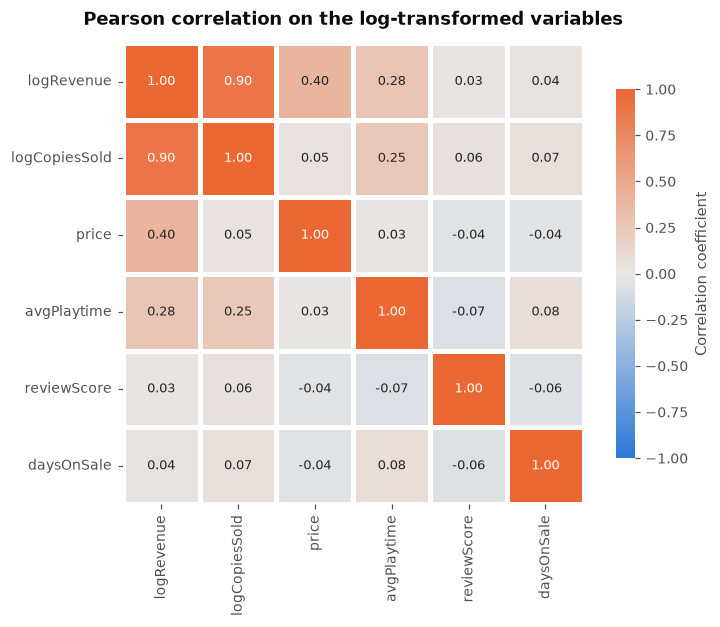

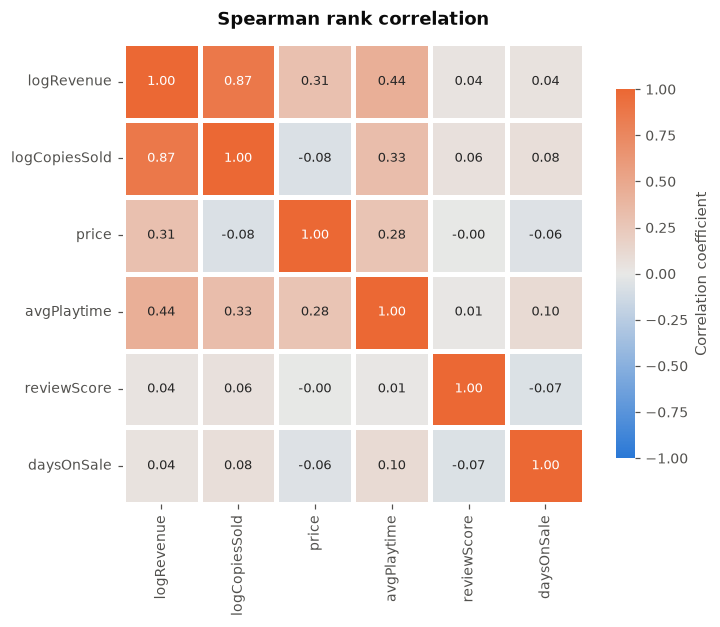

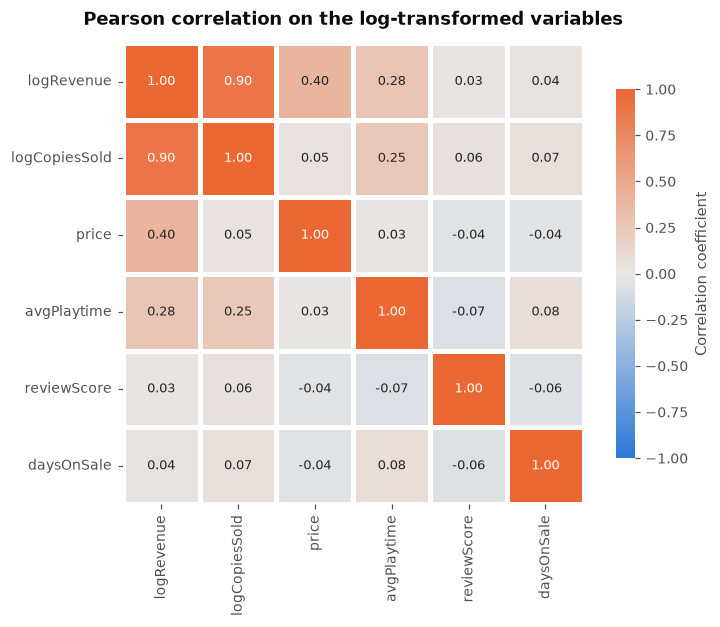

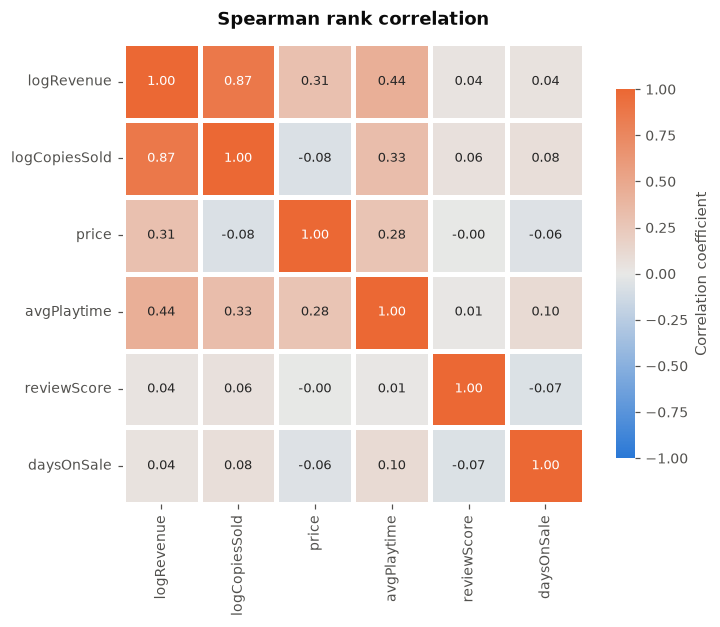

In [70]:
correlation_columns = [
    "logRevenue", "logCopiesSold", "price", "avgPlaytime", "reviewScore", "daysOnSale",
]

display(plot_correlation_heatmap(
    featured_games[correlation_columns].corr(method="pearson"),
    "Pearson correlation on the log-transformed variables",
))
display(plot_correlation_heatmap(
    featured_games[correlation_columns].corr(method="spearman"),
    "Spearman rank correlation",
))

#### The correlation matrix, and what a log transform repairs

Once `revenue` and `copiesSold` are log-transformed, Pearson largely agrees with
Spearman: the `logRevenue`–`logCopiesSold` correlation is **0.897**, against
0.628 on the raw values. Nothing about the data changed. Only the scale did.

This is worth stating plainly, because it is the practical lesson of the
section: **Pearson was not "wrong" about the raw data — it correctly reported
that the raw relationship is not linear.** The mistake would be to read that as
"the variables are unrelated". Log-transforming turns a multiplicative
relationship into an additive one, which is exactly the shape Pearson is built
to measure.

Note also that `price` correlates 0.398 with `logRevenue` but only 0.051 with
`logCopiesSold`. Price drives revenue while being almost unrelated to units
sold — which is the arithmetic of revenue being a product of the two, and a
useful sanity check that the estimation model behaves sensibly.

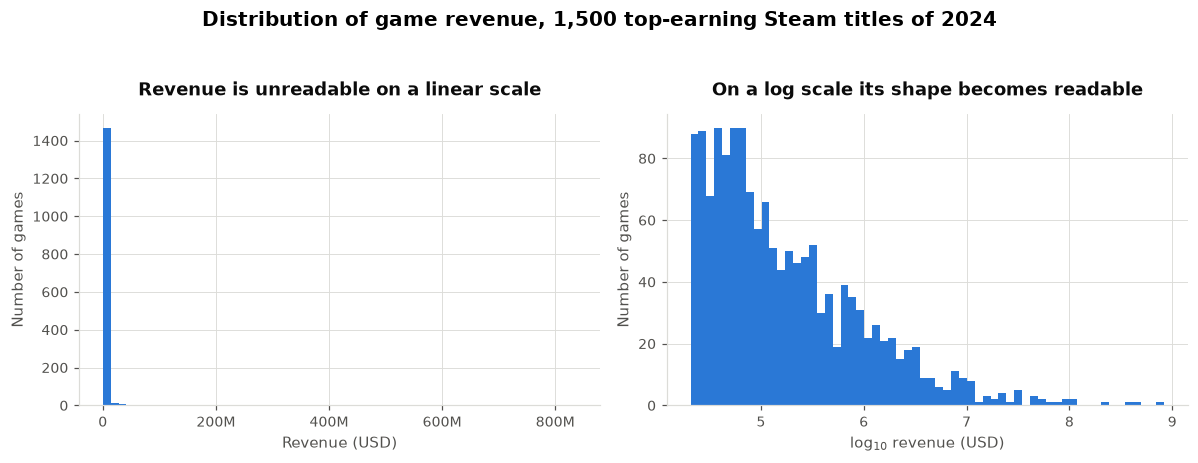

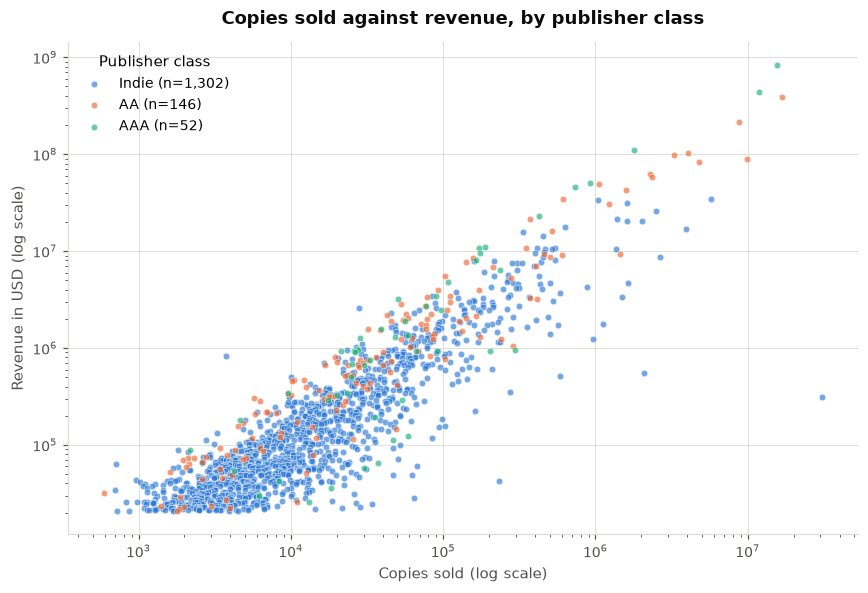

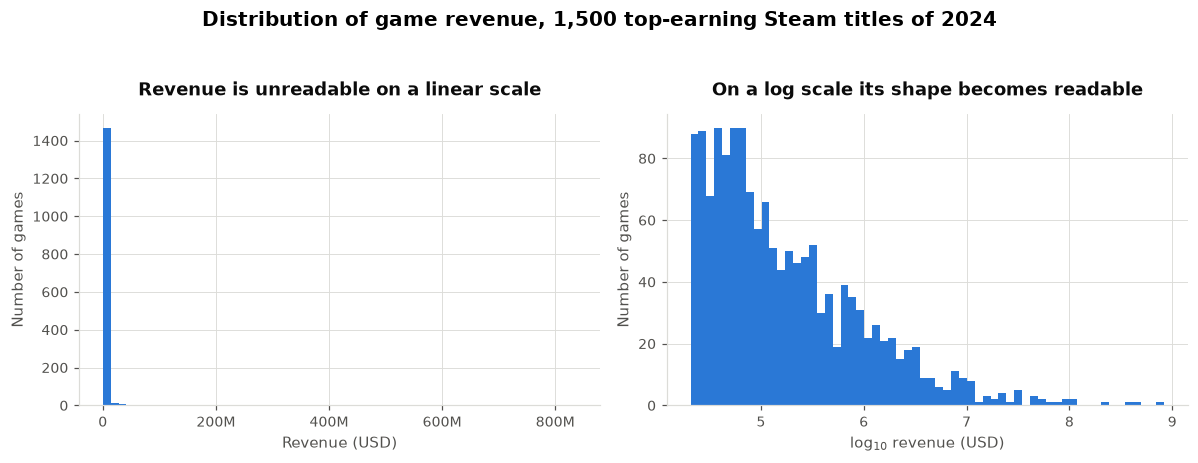

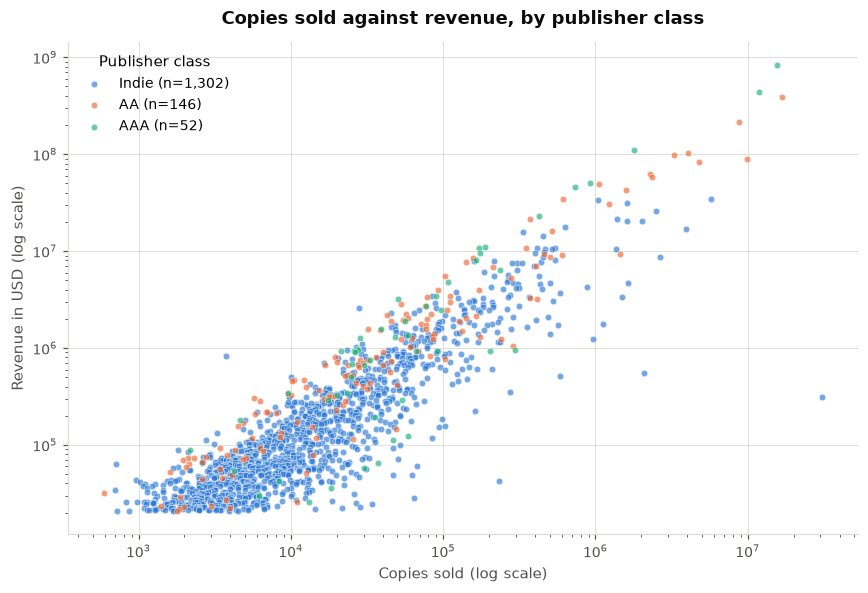

In [71]:
display(plot_revenue_distribution(featured_games))
display(plot_copies_versus_revenue(featured_games))

**Histogram — the shape of revenue.** On the linear scale the entire dataset
collapses into the leftmost bar and the axis runs to $800M to accommodate a
single game. Nothing can be read from it, which is itself the finding: this
variable has no meaningful linear scale. On the log axis the distribution
becomes legible, with a mode around $10⁴·⁵ and a long right tail. It remains
right-skewed even after the transform (skew 1.19), so log space makes it
tractable, not normal.

**Scatterplot — copies against revenue.** On log-log axes the relationship is
tight and close to a straight line, which is what a 0.897 correlation looks
like. Three further things are visible. The vertical spread at any given copy
count is the effect of price. The AA and AAA points sit disproportionately in
the upper right, but they overlap heavily with Indie rather than forming a
separate population. And the free-to-play games appear as the visible cluster
below the main band — high copies, low revenue — because their money does not
come from the sale price.

### 6.2 Categorical to Categorical

Section 5.2 established that `publishers` and `developers` cannot be used as
categories directly. The categorical variables analysed here are therefore
`publisherClass`, two flags derived from the data, and four bands obtained by
binning the numeric columns.

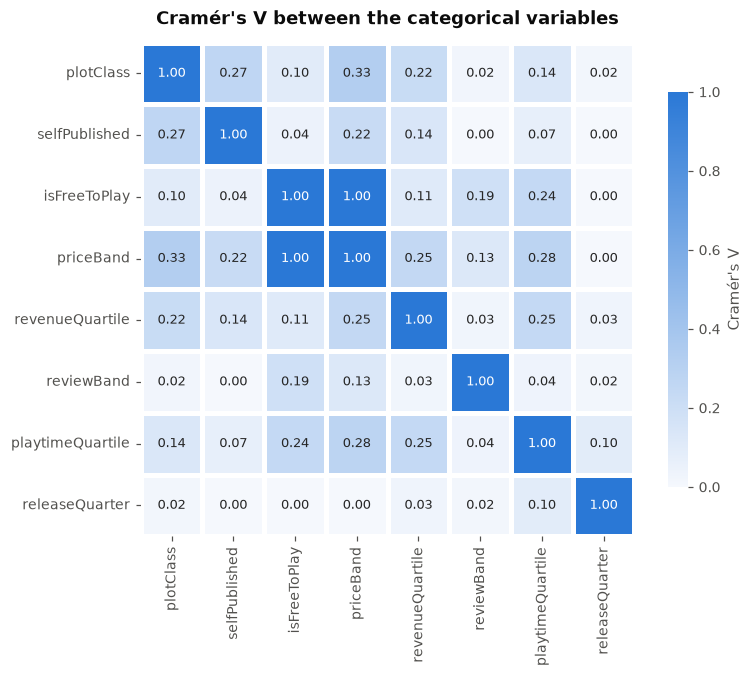

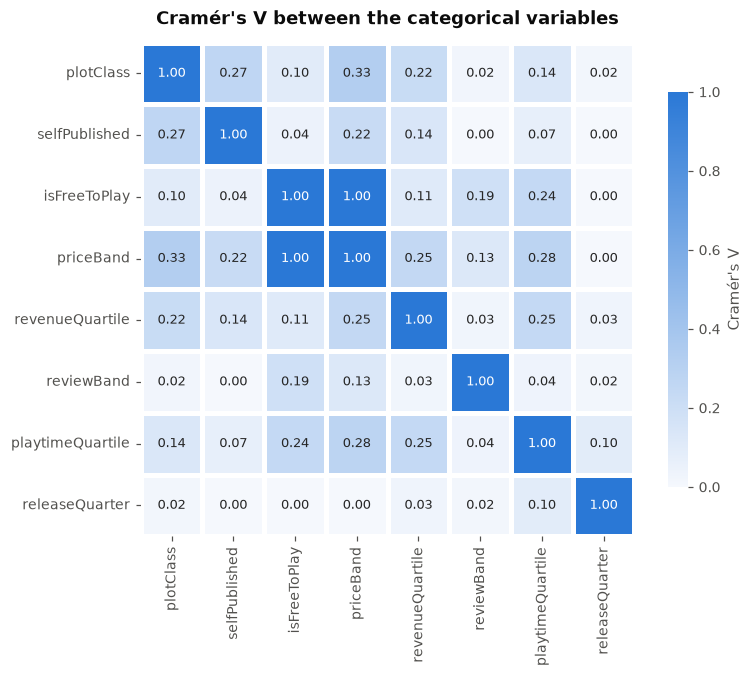

In [72]:
categorical_columns = [
    "plotClass", "selfPublished", "isFreeToPlay", "priceBand",
    "revenueQuartile", "reviewBand", "playtimeQuartile", "releaseQuarter",
]

association_matrix = cramers_v_matrix(featured_games, categorical_columns)
display(plot_association_heatmap(association_matrix, "Cramér's V between the categorical variables"))

In [73]:
display(pd.crosstab(
    featured_games["plotClass"], featured_games["priceBand"], margins=True, margins_name="All",
))
display(pd.crosstab(
    featured_games["plotClass"], featured_games["revenueQuartile"], normalize="index",
).round(3))

priceBand,Free,$0.01-9.99,$10-19.99,$20-39.99,$40+,All
plotClass,,,,,,
Indie,73,397,583,231,18,1302
AA,3,11,42,62,28,146
AAA,9,9,4,11,19,52
All,85,417,629,304,65,1500


revenueQuartile,Q1 lowest,Q2,Q3,Q4 highest
plotClass,,,,
Indie,0.275,0.270,0.257,0.198
AA,0.082,0.130,0.219,0.568
AAA,0.096,0.077,0.173,0.654


#### What the associations show

**First, a warning that the matrix itself provides.** `isFreeToPlay` and
`priceBand` show a Cramér's V of **1.00**. That is not a discovery — the flag was
*derived* from price, so the association is a tautology. It is left in
deliberately, because it demonstrates how easily an engineered feature can
manufacture a perfect correlation with its own parent. Any association measured
between a derived variable and its source is meaningless, and in a larger
feature set this kind of leakage is easy to miss.

**The genuine associations are all moderate, and none exceed 0.34.**

| Pair | Cramér's V | Reading |
|---|---|---|
| `plotClass` × `priceBand` | 0.33 | Bigger studios charge more |
| `priceBand` × `playtimeQuartile` | 0.28 | Costlier games are played longer |
| `plotClass` × `selfPublished` | 0.27 | Indie studios self-publish; AAA do not |
| `priceBand` × `revenueQuartile` | 0.25 | Price relates to revenue band |
| `revenueQuartile` × `playtimeQuartile` | 0.25 | Longer-played games earn more |

**Two variables are associated with essentially nothing.** `reviewBand` scores
0.02–0.19 against every other variable, and `releaseQuarter` scores 0.00–0.10.
Quality ratings and release timing are statistically independent of every
commercial and structural variable measured here — a null result, but a strong
and consistent one across both 6.1 and 6.2.

The contingency tables make the price relationship concrete: AAA titles cluster
in the `$40+` band while Indie games concentrate below $20, and the row-normalised
revenue table shows AAA games are overwhelmingly in the top revenue quartile
while Indie games spread across all four.

In [74]:
display(summarise_by_category(featured_games, "plotClass", "revenue"))
display(summarise_by_category(featured_games, "priceBand", "revenue"))

,Games,Median,Mean,Total,Share of total
plotClass,,,,,
Indie,1302,90773.0,673638.65,8.770775e+08,22.21
AA,146,672187.0,10170532.86,1.484898e+09,37.61
AAA,52,928862.0,30511493.31,1.586598e+09,40.18


,Games,Median,Mean,Total,Share of total
priceBand,,,,,
Free,85,312915.81,2820022.85,2.397019e+08,6.07
$0.01-9.99,417,59326.00,257348.36,1.073143e+08,2.72
$10-19.99,629,105087.00,476883.36,2.999596e+08,7.60
$20-39.99,304,333978.00,6212755.92,1.888678e+09,47.83
$40+,65,1898159.00,21737220.52,1.412919e+09,35.78


#### Relating categorical variables to numeric ones through binning

Grouping the numeric `revenue` by the categorical bands turns the association
measures above into interpretable magnitudes:

- **Median revenue rises from $90,773 for Indie to $928,862 for AAA — a factor
  of ten.** But Indie games still account for 22.2% of all revenue in the
  dataset, because there are 25 times more of them.
- The price bands show the same monotone pattern, with the **free-to-play band
  breaking it**: those games earn far more than their price band would suggest,
  since their revenue arrives through a different mechanism entirely.

### 6.3 Graphs

The remaining required chart types are collected here. All figures are built by
`src/plotting.py` so that colour, typography and grid treatment are defined once.
Colours are assigned to publisher classes in a fixed order and never by rank, and
the three-colour categorical set is one validated for colour-vision deficiency.

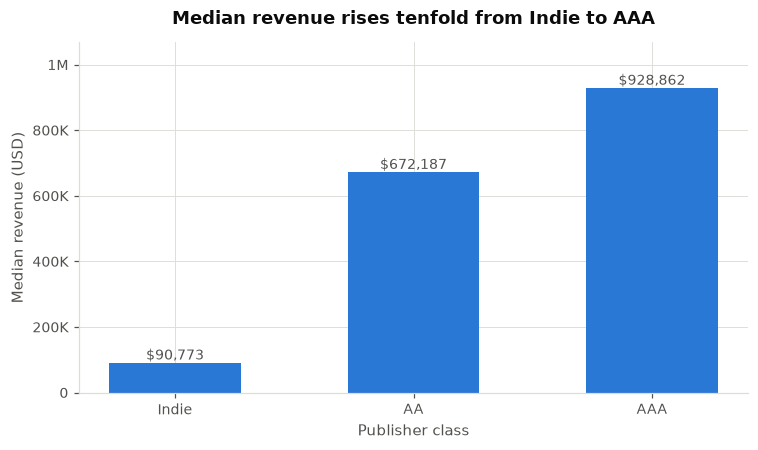

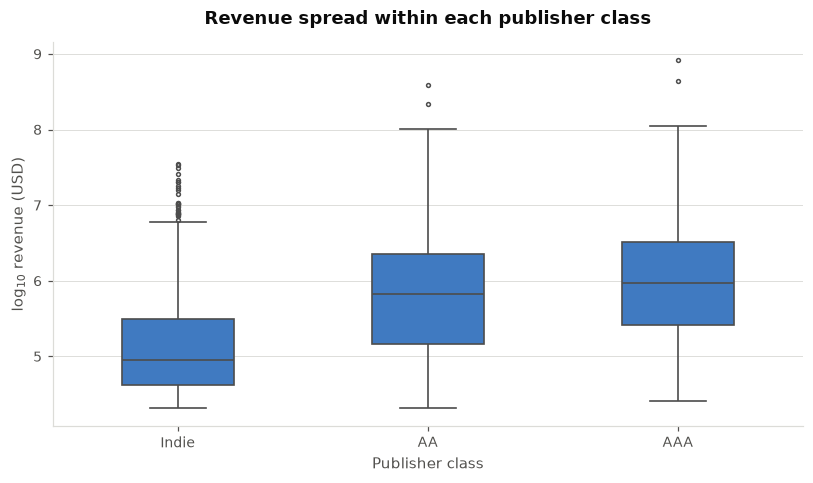

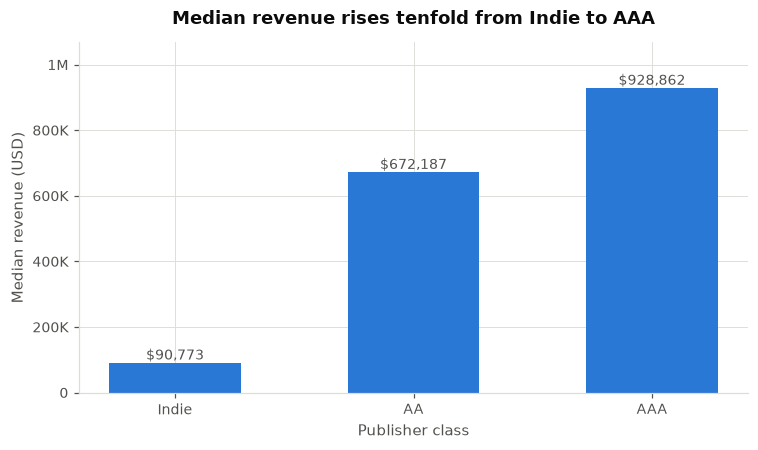

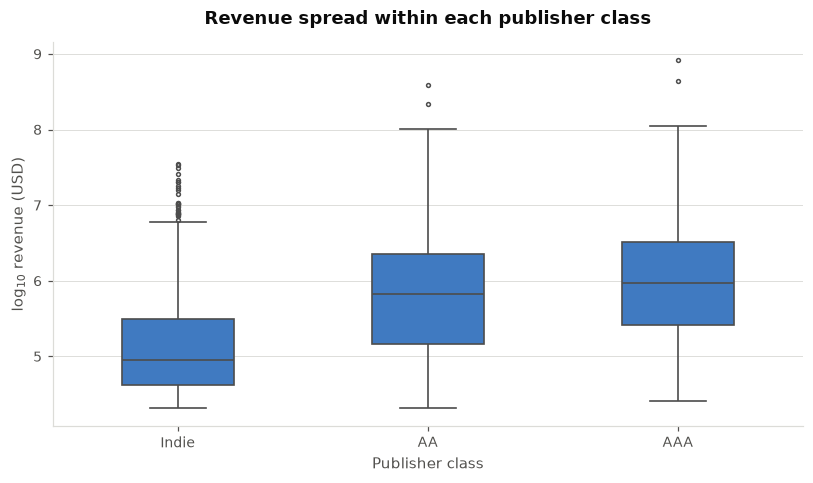

In [75]:
display(plot_median_revenue_by_class(featured_games))
display(plot_revenue_box_by_class(featured_games))

**Bar chart — median revenue by class.** The tenfold climb from Indie to AAA is
the clearest single comparison in the dataset. Medians are used rather than
means for the reasons established in section 5.

**Box plot — revenue spread within each class.** This qualifies the bar chart
sharply. The boxes overlap substantially: the Indie upper whisker reaches well
into the AA and AAA range. Class predicts the *typical* outcome but not the
*possible* one, and the most successful Indie games outperform the median AAA
title. Indie also shows many more outliers above its box — the long tail of
breakout hits that the class label cannot anticipate.

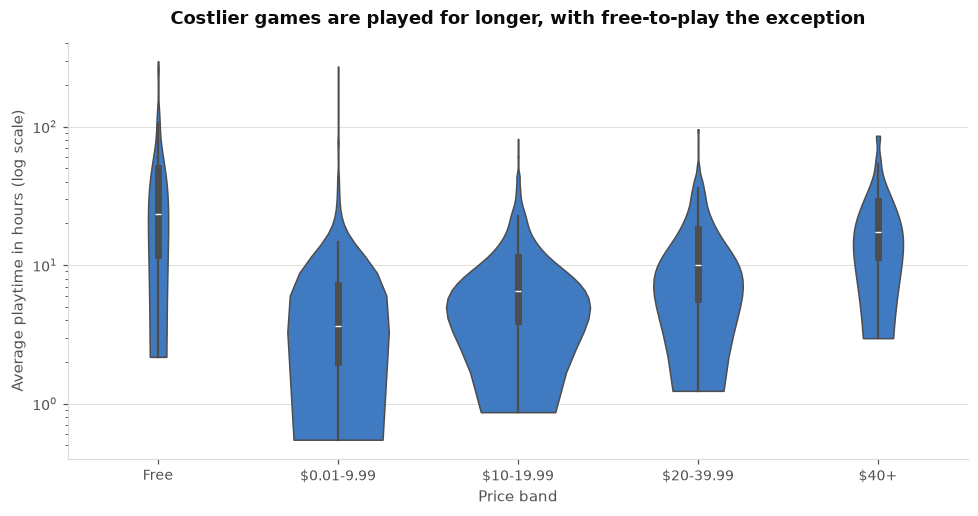

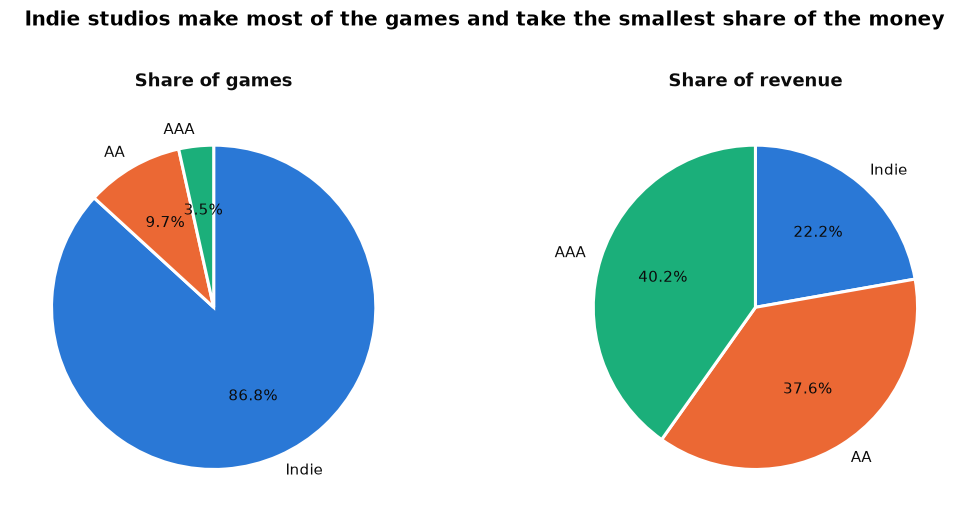

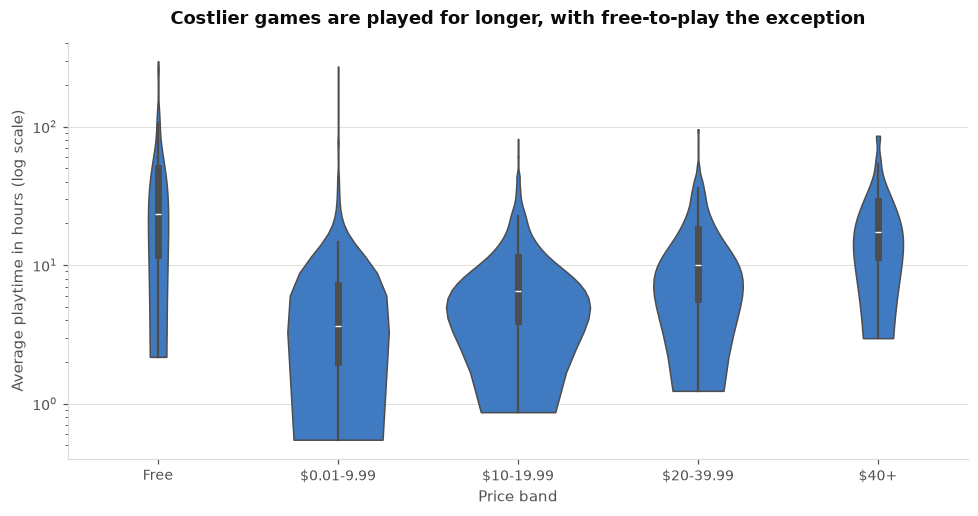

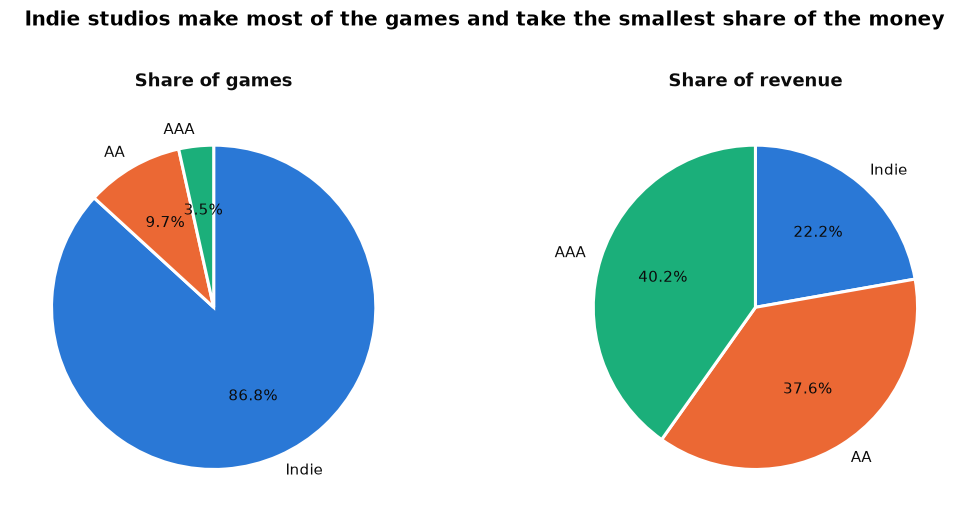

In [76]:
display(plot_playtime_violin_by_price(featured_games))
display(plot_share_comparison_pies(featured_games))

**Violin plot — playtime across price bands.** The violin shows the full
distribution shape, which the box plot compresses. Playtime rises with price
from the $0.01–9.99 band upward, but **free-to-play games break the pattern
completely**: they have the highest median playtime of any band. This fits the
business model — free live-service games are built to retain players over months
rather than to be finished — and it is a relationship that no correlation
coefficient on `price` could have revealed, because it is non-monotonic.

**Pie charts — share of games against share of revenue.** These two charts carry
the central contrast of the whole analysis. Indie studios produce **86.8% of the
games** but capture **22.2% of the revenue**. AAA studios produce **3.5%** and
capture **40.2%**. Part-to-whole comparison is the one job a pie chart does well,
and placing the two side by side makes the asymmetry immediate.

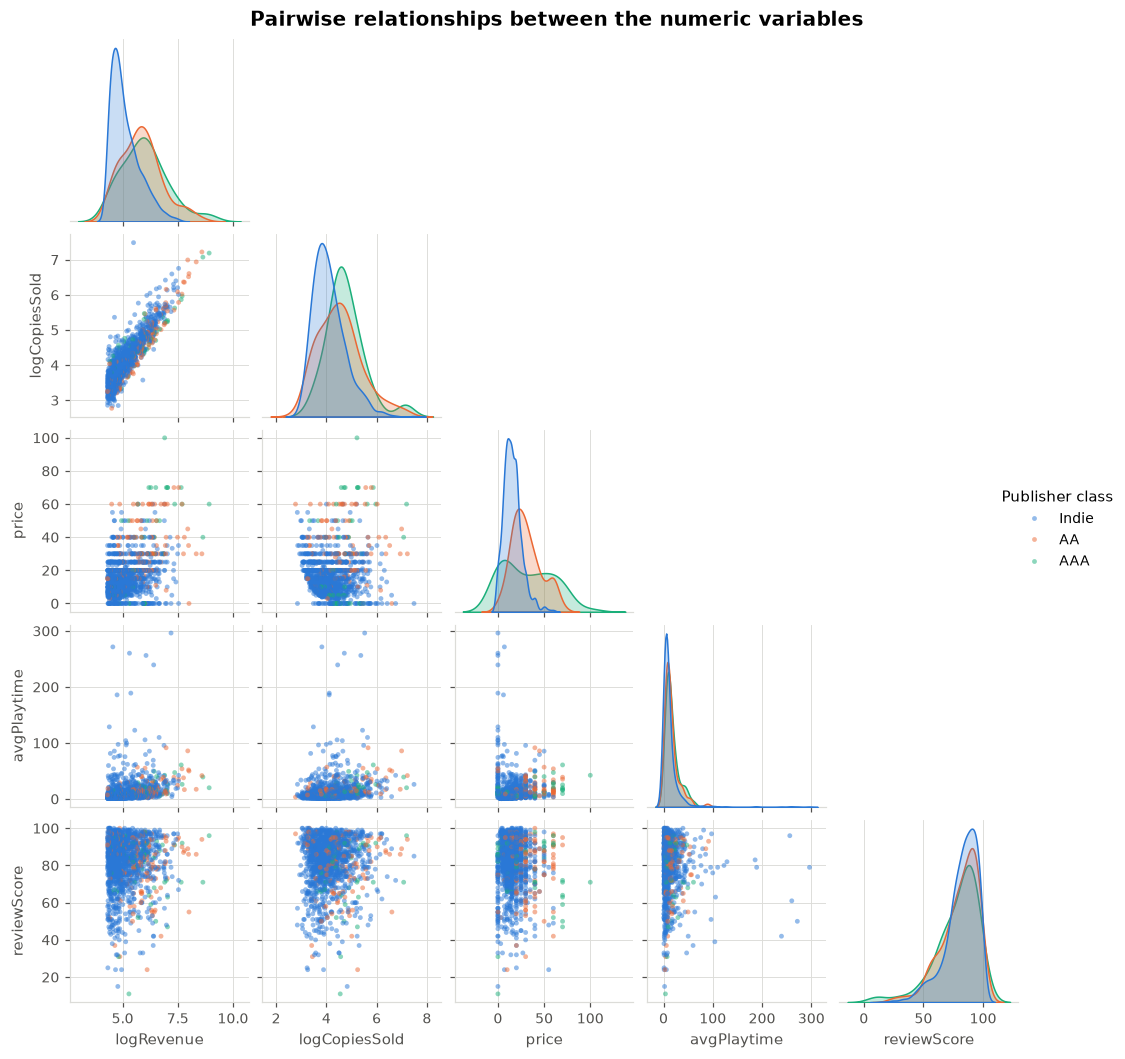

In [77]:
display(plot_numeric_pairplot(featured_games))

**Pairplot — every numeric pair at once.** The diagonal shows each variable's
distribution by class, and the lower triangle every pairwise relationship. Three
things stand out: `logRevenue` and `logCopiesSold` form the tight diagonal band
already quantified at 0.897; `reviewScore` shows no visible structure against
anything, confirming the null results above; and `price` forms vertical stripes
rather than a cloud, the visual signature of the 58 discrete price points found
in section 4.4.

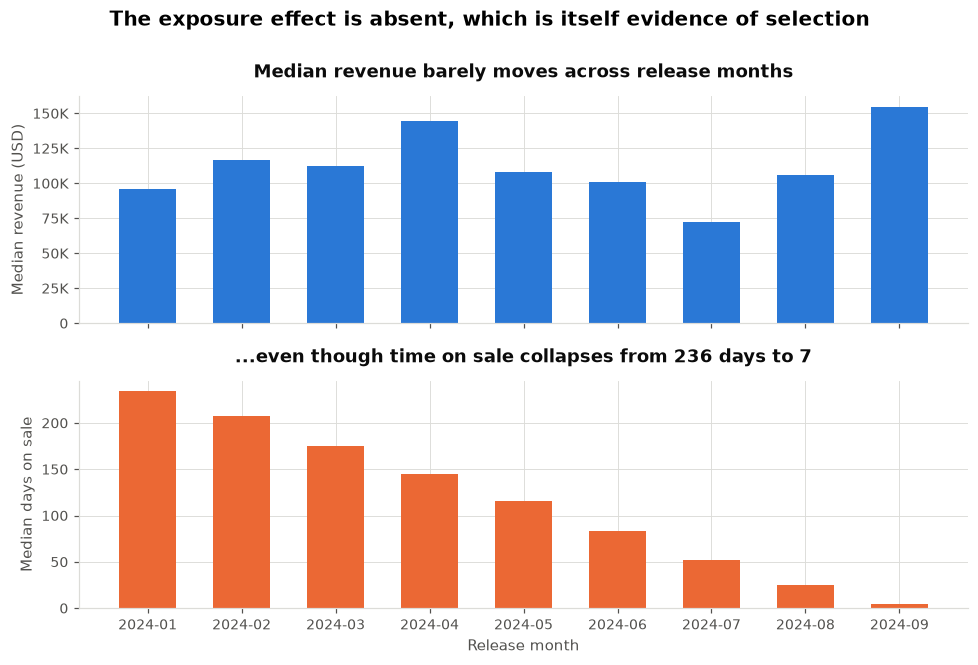

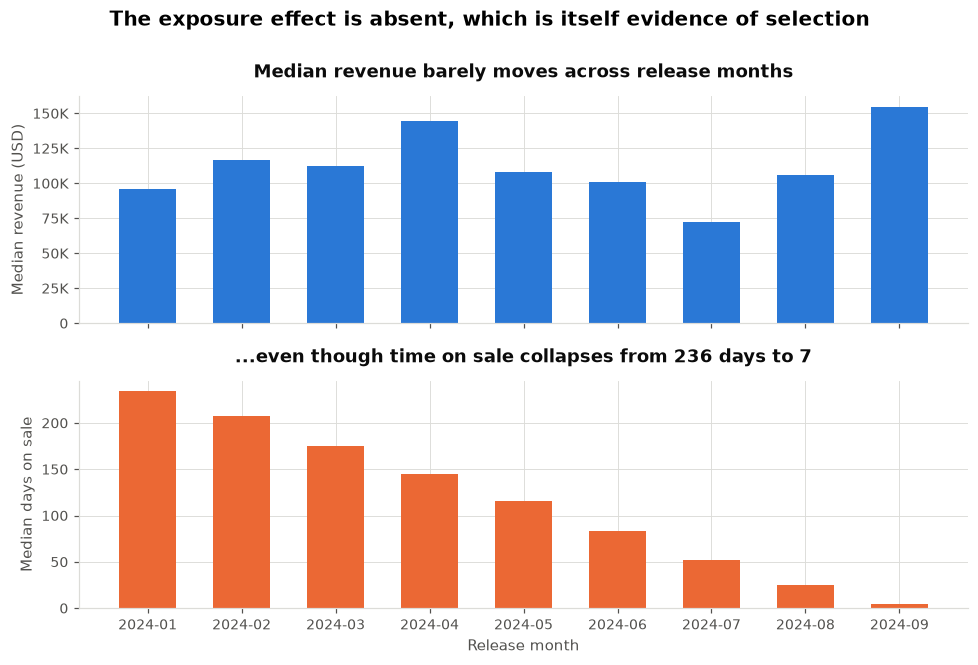

In [78]:
display(plot_monthly_revenue_trend(featured_games))

#### The exposure paradox, and what it reveals about the sample

Section 3.1 established that games released in January had 252 days to earn
while those released in September had 3, and predicted that this would confound
any comparison of revenue over time. **The data contradicts that prediction**,
and the contradiction is more interesting than the prediction was.

Median revenue is essentially flat across release months — $96k in January
against $155k in September — even though median time on sale collapses from 234
days to 4. Games released a week before the snapshot earn as much as games that
had been selling for eight months.

**This is not evidence that exposure does not matter. It is evidence of how the
sample was built.** Membership of this dataset requires being among the top
1,500 earners. A game released in early September has had one week to qualify,
so only an exceptional performer can appear at all, while a January game can
reach the same total slowly. Selecting on the outcome removes the relationship
between exposure and that outcome — a *collider* effect.

Two consequences follow. The exposure confound identified in section 3.1 is
real, but it is **hidden** here rather than absent, so it cannot be corrected by
adjusting for `daysOnSale` within this dataset. And the flatness is a
*measurement* of the selection: the later a game's release, the more extreme it
must be to appear, which means the sample's severity increases through the year.
Median copies sold does still decline across months, from 15,552 to 8,042,
which shows the underlying exposure effect surviving in the variable that was
*not* used as the selection criterion.

## 7. Index Analysis

Section 4.2 noticed that the three tied revenue values sat next to each other in
the file, which suggested the rows were ordered by revenue. They are not, and
following that thread produces the most practically dangerous finding in this
notebook.

In [79]:
describe_index(steam_games, sort_candidates=["revenue", "copiesSold", "steamId", "releaseDate"])

,Property,Value
0,Index type,RangeIndex
1,Index range,0 to 1499
2,Index is unique,Yes
3,Index carries meaning,"No — it is positional, assigned on load"
4,Index is time-based,No
5,Rows ordered by revenue,Not sorted
6,Rows ordered by copiesSold,Not sorted
7,Rows ordered by steamId,Not sorted
8,Rows ordered by releaseDate,Not sorted


#### Is the index unique, and is it time-based?

**The index is unique, but only trivially so.** It is a positional
`RangeIndex` from 0 to 1,499 created by pandas at load time, not a key that came
with the data. It is unique the way row numbers are always unique, and it
carries no information: row 42 means nothing beyond "the forty-third line of the
file".

**A meaningful index is available.** Section 4.2 established that `steamId`
repeats zero times, so it is a genuine primary key — and unlike the row number
it is stable across extracts and joinable against any other Steam data source.
It is the natural index for this table. It should be stored as text rather than
`int64`, for the reason given in section 3.2: arithmetic on an identifier is
meaningless.

**The index is not time-based, and could not easily be made so.** `releaseDate`
covers 235 distinct days across 1,500 games, so a `DatetimeIndex` built from it
would be heavily non-unique — the busiest single day carries 27 games. A time
index would be appropriate for a series of events; this is a catalogue of
entities that happen to have dates.

In [80]:
revenue_blocks = detect_descending_blocks(steam_games["revenue"])
revenue_blocks

,Block,First row,Last row,Rows,Highest value,Lowest value
0,A,0,549,550,8055097.0,59016.0
1,B,550,1099,550,3139302.0,20674.0
2,C,1100,1449,350,1868809.0,264059.0
3,D,1450,1499,50,837793356.0,8125042.0


In [81]:
first_ten_by_position = steam_games.head(10)[["name", "revenue"]].reset_index(drop=True)
true_top_ten = steam_games.nlargest(10, "revenue")[["name", "revenue"]].reset_index(drop=True)

comparison = pd.DataFrame(
    {
        "What .head(10) returns": first_ten_by_position["name"],
        "Revenue at that row": first_ten_by_position["revenue"],
        "The actual top 10 by revenue": true_top_ten["name"],
        "Its revenue": true_top_ten["revenue"],
    }
)
print(f"Games appearing in both lists: {len(set(first_ten_by_position['name']) & set(true_top_ten['name']))}")
comparison

Games appearing in both lists: 0


,What .head(10) returns,Revenue at that row,The actual top 10 by revenue,Its revenue
0,WWE 2K24,8055097.0,Black Myth: Wukong,837793356.0
1,EARTH DEFENSE FORCE 6,7882151.0,HELLDIVERS™ 2,435635596.0
2,Sins of a Solar Empire II,7815247.0,Palworld,392328553.0
3,Legend of Mortal,7756399.0,Sons Of The Forest,217017892.0
4,Shin Megami Tensei V: Vengeance,7629252.0,Dragon's Dogma 2,111478291.0
5,Soulmask,7540563.0,The First Descendant,102244808.0
6,The Universim,7534369.0,Last Epoch,97723674.0
7,Bellwright,7481940.0,7 Days to Die,89781931.0
8,Night of the Dead,7091792.0,V Rising,83614738.0
9,Empires of the Undergrowth,6950952.0,Manor Lords,63098408.0


#### Is it sorted? Almost, and that is worse than not at all

**No column sorts the file.** Revenue, copies sold, `steamId` and release date
are all non-monotonic. But revenue is *nearly* monotonic: across 1,499
consecutive row pairs, revenue steps back up only **three times**. The file is a
concatenation of four separately sorted extracts:

| Block | Rows | Count | Revenue range |
|---|---|---|---|
| A | 0–549 | 550 | $8,055,097 → $59,016 |
| B | 550–1,099 | 550 | $3,139,302 → $20,674 |
| C | 1,100–1,449 | 350 | $1,868,809 → $264,059 |
| D | **1,450–1,499** | **50** | **$837,793,356 → $8,125,042** |

Block D holds the real blockbusters — *Black Myth: Wukong*, *HELLDIVERS 2*,
*Palworld* — and it sits at the **end** of the file. Its lowest value
($8,125,042) is just above block A's highest ($8,055,097), so block D is exactly
the top 50 games overall, stored last. Blocks A, B and C overlap heavily in
revenue and cannot be rank ranges; what distinguishes them cannot be recovered
from the file alone. The block sizes — 550, 550, 350, 50 — are suspiciously
round, which points to several paginated or filtered extracts concatenated by
whoever assembled the upload.

**The practical consequence is severe, and the comparison above demonstrates
it.** `steam_games.head(10)` is the single most common first command in any
analysis. Here it returns ten games earning $7–8 million, while the actual ten
largest earn $63 million to $838 million. **Not one game appears in both lists.**
An analyst who glanced at the head of this file and formed an impression of "top
Steam games in 2024" would be wrong by two orders of magnitude and would have no
indication anything was amiss — the output looks entirely reasonable.

This is a good illustration of a general hazard: **near-order is more dangerous
than disorder.** Obviously unsorted data prompts an explicit sort. Data that
looks sorted for the first 550 rows invites trust it has not earned.

In [82]:
quarterly_stability = featured_games.groupby("releaseQuarter", observed=True).agg(
    games=("revenue", "size"),
    median_revenue=("revenue", "median"),
    median_price=("price", "median"),
    median_review=("reviewScore", "median"),
    indie_share=("plotClass", lambda column: (column == "Indie").mean() * 100),
)
quarterly_stability["copies_revenue_spearman"] = [
    group["copiesSold"].corr(group["revenue"], method="spearman")
    for _, group in featured_games.groupby("releaseQuarter", observed=True)
]
quarterly_stability.round(3)

,games,median_revenue,median_price,median_review,indie_share,copies_revenue_spearman
releaseQuarter,,,,,,
Q1,527,113195.0,14.99,84.0,84.820,0.871
Q2,607,116681.0,14.99,84.0,88.633,0.866
Q3,366,85340.5,14.99,86.0,86.612,0.864


#### Does the analysis above change over time?

**Almost not at all, which is a reassuring result rather than a dull one.**
Splitting the dataset by release quarter and recomputing the central findings
gives:

| | Q1 | Q2 | Q3 |
|---|---|---|---|
| Games | 527 | 607 | 366 |
| Median revenue | $113,195 | $116,681 | $85,341 |
| Median price | $14.99 | $14.99 | $14.99 |
| Median review score | 84 | 84 | 86 |
| Indie share | 84.8% | 88.6% | 86.6% |
| Spearman, copies vs revenue | 0.871 | 0.866 | 0.864 |

The copies-to-revenue rank correlation varies by less than 0.01 across the
three quarters. The market's composition, pricing and quality profile do not
drift across the period covered.

Two qualifications keep this from being over-read. Q3 is incomplete — it ends on
6 September and holds fewer games — so its slightly lower median revenue is the
truncation and exposure effect from section 6, not a market downturn. And
stability across nine months of a single year says nothing about stability
across years; **Q4 is absent entirely**, and it is the quarter where the holiday
sales fall.

**The conclusion for the index as a whole:** the row order should be discarded,
`steamId` adopted as the index, and any ranking recomputed explicitly with
`sort_values` rather than trusted from the file.

## 8. Insights and the Data Story

### The story in one paragraph

This dataset presents itself as a record of the 1,500 highest-earning games
released on Steam in 2024. It is better understood as **one analytics vendor's
estimate of that market, extracted on 9 September 2024, assembled from four
separate queries, and published without its methodology**. Almost every
substantive finding below came from interrogating that description rather than
from the numbers themselves. The values are clean — no negatives, no impossible
entries, three missing cells out of 16,500 — and that cleanliness is misleading:
the dataset's real problems are encoded as perfectly valid numbers.

The cell below recomputes every headline claim in this section directly from the
data, so that no figure quoted here can drift from what the notebook actually
produced.

In [83]:
top_five_share = featured_games.nlargest(5, "revenue")["revenue"].sum() / featured_games["revenue"].sum()
publishers_for_half = int((expand_entity_column(featured_games, "publishers").value_counts().cumsum()
                           / len(expand_entity_column(featured_games, "publishers")) < 0.5).sum() + 1)
class_totals = featured_games.groupby("plotClass", observed=True)["revenue"].sum()
indie_revenue_share = class_totals["Indie"] / class_totals.sum()
indie_game_share = (featured_games["plotClass"] == "Indie").mean()
score_vs_revenue = featured_games["reviewScore"].corr(featured_games["revenue"], method="spearman")
review_first_quartile = featured_games["reviewScore"].quantile(0.25)
placeholder_count = int((steam_games["reviewScore"] == 0).sum())
mean_shift = featured_games["reviewScore"].mean() - steam_games["reviewScore"].mean()
head_overlap = len(set(steam_games.head(10)["name"]) & set(steam_games.nlargest(10, "revenue")["name"]))
exposure_span = (featured_games["daysOnSale"].min(), featured_games["daysOnSale"].max())
below_mean = (featured_games["revenue"] < featured_games["revenue"].mean()).mean()

findings_ledger = pd.DataFrame(
    [
        ("Revenue is extremely concentrated",
         f"the 5 largest games hold {top_five_share:.1%} of all revenue; {below_mean:.1%} of games earn below the mean", "5"),
        ("Authorship is not concentrated",
         f"{publishers_for_half} different publishers are needed to cover half the games", "5.2"),
        ("Indie makes the games, AAA takes the money",
         f"Indie is {indie_game_share:.1%} of games but {indie_revenue_share:.1%} of revenue", "6.2"),
        ("Review score does not track revenue here",
         f"Spearman = {score_vs_revenue:.3f}, but the first quartile of scores is already {review_first_quartile:.0f}", "6.1"),
        ("Placeholders were stored as valid numbers",
         f"{placeholder_count} review scores of 0 shifted the mean by {mean_shift:+.1f} points", "4.3"),
        ("Row order is not what it appears",
         f"head(10) and the true top 10 share {head_overlap} games", "7"),
        ("Exposure is unequal but invisible",
         f"time on sale spans {exposure_span[0]}-{exposure_span[1]} days, yet median revenue is flat by month", "6.3"),
    ],
    columns=["Insight", "Evidence recomputed from the data", "Section"],
)
findings_ledger

,Insight,Evidence recomputed from the data,Section
0,Revenue is extremely concentrated,the 5 largest games hold 50.5% of all revenue;...,5
1,Authorship is not concentrated,328 different publishers are needed to cover h...,5.2
2,"Indie makes the games, AAA takes the money",Indie is 86.8% of games but 22.2% of revenue,6.2
3,Review score does not track revenue here,"Spearman = 0.037, but the first quartile of sc...",6.1
4,Placeholders were stored as valid numbers,99 review scores of 0 shifted the mean by +5.4...,4.3
5,Row order is not what it appears,head(10) and the true top 10 share 0 games,7
6,Exposure is unequal but invisible,"time on sale spans 3-252 days, yet median reve...",6.3


### Three central insights

#### Insight 1 — The money and the people obey different laws

This is the finding that most changed how I read the dataset. Revenue follows a
power law so severe that **five games hold half of it** and one title,
*Black Myth: Wukong*, holds 21.2% by itself. Authorship follows nothing of the
sort: it takes **328 publishers to account for half the games**, the largest
holds 1.31%, and 83.1% of publishers appear exactly once.

Both facts are true of the same 1,500 rows. The consequence is that the common
claim "the games industry is dominated by a few large players" is **true of
revenue and false of participation**. Concentration of income coexists with an
almost completely unconcentrated field of producers — Indie studios make 86.8%
of these games while collecting 22.2% of the money, and AAA studios make 3.5%
while collecting 40.2%.

A single average would have hidden this entirely. It only became visible because
the same variable was examined for both its central tendency and its
concentration.

#### Insight 2 — Within this tier, measured quality does not predict commercial outcome

`reviewScore` is uncorrelated with revenue by **all three** methods — Pearson
0.025, Spearman 0.037, Kendall 0.026 — and its binned form has a Cramér's V of
0.04 or less against publisher class, revenue quartile and playtime quartile.
For a variable that intuitively ought to drive sales, this is a striking null.

**The honest reading requires a caveat that is itself the insight.** This is a
sample of the top 1,500 earners, and its review scores are correspondingly
compressed: the first quartile is already 75 and the median is 85. Both variables
are range-restricted, and restriction of range attenuates correlation
mechanically. The defensible claim is therefore narrow:

> Among games that were already commercially successful in 2024, review score
> does not discriminate between the moderately and the enormously successful.

The claim that would **not** be defensible is "quality does not affect sales".
That question cannot be asked of this dataset at all, because every game that
failed has already been removed from it.

#### Insight 3 — This is not a record of what happened; it is the output of a model

Steam publishes no per-title sales or revenue figures, so `revenue` and
`copiesSold` cannot be measurements. Four independent pieces of internal
evidence support this, and none of them required outside information:

1. `avgPlaytime` is unique across all 1,500 rows to roughly fourteen decimal
   places — the signature of a computed quantity, not a recorded one.
2. `revenue` is not `copiesSold × price`: two different quantity-and-price pairs
   produce byte-identical revenue, and 85 free-to-play games report revenue that
   no such product could generate.
3. The file retains `reviewScore` but discards **review count** — the very input
   from which sales estimates of this kind are derived. The model's output is
   published while its principal input is withheld.
4. No methodology, uncertainty or provenance ships with the data.

The practical consequence bounds everything else in this notebook: the figures
support **relative** statements — rankings, comparisons, associations — but not
**absolute** financial claims about any individual title.

### Bias and risk

Three biases matter enough to constrain how this data may be used. The first
generates most of the others.

**Survivorship and selection bias — the master bias.** Rows were selected
*because* revenue was high. Every distributional statement therefore describes
the top 1,500 earners, never "games on Steam". This is not a caveat to note and
move past: it actively **erased a real effect**. Section 3.1 established that
time on sale ranged from 3 to 252 days and predicted that unequal exposure would
confound revenue. Section 6.3 found median revenue flat across release months
instead. The explanation is that qualifying for a top-1,500 list after one week
on sale requires being exceptional, so conditioning on the outcome removed its
relationship with exposure — a collider effect. The confirmation is that
`copiesSold`, which was *not* the selection criterion, still declines across the
year, from a median of 15,552 in January to 8,042 in September.

The risk this creates is subtle: the confound is **hidden rather than absent**,
so it cannot be corrected by adjusting for `daysOnSale` within this dataset. An
analyst who tested for the exposure effect, found none, and concluded that
release timing does not matter would have drawn a confident conclusion from a
statistical artefact.

**Estimation bias.** Every monetary value is model output with unknown
systematic error and no confidence interval. Because such models are typically
driven by review counts, they inherit whatever biases affect reviewing
behaviour — which varies by genre, by price, and by language market. The dataset
contains CJK studio names and non-Latin titles, exactly the segment where
review-driven estimation is least reliable, and nothing in the file marks which
estimates are more or less trustworthy.

**Temporal truncation.** Coverage ends on 6 September 2024, so **the entire
fourth quarter is missing** — the Black Friday and winter sale period, and the
commercially most important weeks of the year. A dataset titled as 2024's top
games describes two-thirds of 2024 and systematically under-represents titles
timed for the holiday season.

### Failure points for engineering and statistical use

These are the specific ways this dataset would break a downstream system or a
downstream conclusion. Each was observed in the analysis above.

**Engineering failures**

| Failure | Cause | Consequence |
|---|---|---|
| `head(10)` to preview the leaders | The file is four concatenated sorted blocks | Returns games earning $7–8M instead of $63–838M, with **zero overlap** with the real top 10 |
| Joining on `name` | Two titles carry trailing whitespace | Silent non-matches, no error raised |
| One-hot encoding `publishers` | 1,169 categories for 1,500 rows, 83% appearing once | Unusable feature matrix |
| Treating `publishers` as atomic | 174 rows hold 2–3 companies, 101 hold up to 6 | `Aspyr,Crystal Dynamics` counted as unrelated to `Aspyr` |
| Splitting company lists on `,` | Legal names contain commas (`CAPCOM Co., Ltd.`) | Corrupts real company names; split on a comma **not followed by a space** |
| Aggregating `steamId` | Stored as `int64` | A mean identifier is silently computed and is meaningless |
| Deduplicating on `revenue` | Three values legitimately repeat | Deletes three real games |
| Deriving a flag from a column, then testing association | `isFreeToPlay` comes from `price` | Cramér's V of 1.00 — a tautology that looks like a discovery |
| Assuming column names document units | No currency, no playtime unit, no score definition | Silent unit errors |

**Statistical failures**

| Failure | Cause | Consequence |
|---|---|---|
| Running `df.corr()` unmodified | Defaults to Pearson | Playtime vs revenue reads 0.08 instead of 0.44 — a real relationship declared absent |
| Reporting mean revenue | Power-law distribution | 92.2% of games fall below the "average" |
| Removing outliers by z-score | Extremes inflate the standard deviation | Only 8 of 1,500 flagged; the threshold sits at 789× the median |
| Removing outliers by IQR on raw values | Wrong scale for a multiplicative variable | Deletes ~15% of the market, including every blockbuster |
| Leaving `reviewScore = 0` in place | 99 placeholders read as valid scores | Mean biased down by 5.4 points; every correlation distorted |
| Adjusting for `daysOnSale` | Collider from the selection rule | Cannot recover the exposure effect; may introduce new bias |
| Modelling `revenue` from `copiesSold × price` | 85 free-to-play games earn without a sale price | Model fails on 5.7% of rows by construction |
| Any absolute financial statement | Gross versus net unstated | Potential 30% error in every monetary figure |

The most serious combined risk is a predictive one. A model trained on this
table to predict revenue would not learn what makes a game succeed; it would
learn **the rule that selected these rows**, because the target variable is the
selection criterion. It would perform well in cross-validation and fail on any
game not already known to be a top earner.

### What I learned, and where my view changed

**I expected review score to predict commercial success. It does not**, at least
not within this tier, and the more valuable lesson was in how to phrase that
result. My first reading — "quality does not drive sales" — is unsupportable,
because the dataset has already deleted every commercial failure. Learning to
state the narrow claim instead of the interesting one was the most useful part
of this exercise.

**I expected exposure time to dominate revenue, and was wrong in an instructive
way.** The prediction in section 3.1 was sound; the data contradicted it; and the
contradiction turned out to be evidence about the *sampling*, not about the
world. A null result is not always the absence of an effect — sometimes it is
the fingerprint of how the sample was built. I would not have recognised that
without first having derived the exposure windows and expected something.

**My view of what a "clean" dataset means changed the most.** This file passes
every routine check: no nulls to speak of, no duplicates, no impossible values,
consistent naming. Nearly all of its problems are encoded as *valid numbers* —
a 0 that means "no score", a row order that looks like a ranking, a revenue
column that looks measured. Missingness declared as `NaN` announces itself and
propagates; missingness disguised as data enters silently into every mean,
correlation and chart. I now regard a suspiciously clean dataset as a reason for
more scrutiny rather than less.

**On the domain**, I came in with a mental model where the PC games market is
dominated by large publishers. The revenue figures support that, but the
authorship figures contradict it completely, and holding both at once is a more
accurate picture than either alone.

Finally, the framing the assignment opens with — that data is not truth but the
output of a measurement process — proved literally true here in a way I did not
anticipate. The most useful facts in this analysis did not come from the table
at all. The snapshot date came from a **filesystem timestamp**, the assembly
history came from **row ordering**, and the strongest evidence about the data's
provenance came from a column that was **missing** rather than present.

## 9. Extensions

This section goes beyond the required analysis in four directions: time
dependence and its links to events outside the dataset, engineered features,
formal hypothesis tests, and proposals for further research.

In [84]:
engineered_games = add_engineered_features(featured_games)

engineered_games[
    ["name", "price", "revenuePerCopy", "priceRealisation", "revenuePerDay",
     "releaseWeekday", "publisherReleaseCount"]
].head()

,name,price,revenuePerCopy,priceRealisation,revenuePerDay,releaseWeekday,publisherReleaseCount
0,WWE 2K24,99.99,48.729875,0.487347,43306.973118,Thursday,2
1,EARTH DEFENSE FORCE 6,59.99,49.323248,0.822191,171351.108696,Thursday,2
2,Sins of a Solar Empire II,49.99,36.487110,0.729888,312609.880000,Thursday,2
3,Legend of Mortal,19.99,17.588286,0.879854,89154.011494,Friday,2
4,Shin Megami Tensei V: Vengeance,59.99,53.990998,0.9,86696.045455,Thursday,4


### 9.1 Feature engineering

Four of the derived columns earn their place by answering questions the raw data
cannot.

**`priceRealisation` — and an answer to a question section 2.2 could not settle.**
Dividing revenue per copy by the list price gives the fraction of the sticker
price actually realised per unit. Across the 1,415 paid games the median is
**80.6%**, with a fairly tight interquartile range of 73%–84%.

This bears directly on the gross-versus-net ambiguity flagged in section 2.2.
Valve's platform cut is widely taken to be around 30%. If `revenue` were stated
**net** of that cut, realisation could not sit much above 70% — yet the median
is 80.6% and the 95th percentile reaches 90%. The more consistent reading is
that **`revenue` is gross**, with the ~19% shortfall reflecting discounts and
regional pricing rather than a platform commission.

The competing explanation must be stated, because the data cannot rule it out:
the tightness of that distribution is also consistent with the vendor applying a
roughly fixed realisation factor inside its model, in which case the number
describes the estimator rather than the market. Either way it is informative —
but only one of the two is a fact about games.

**`revenuePerDay` — normalising away the exposure problem.** Section 6.3 found
median revenue flat across release months despite exposure ranging from 3 to 252
days. Dividing by days on sale removes that difference, and the result is
dramatic: median revenue per day climbs from **$423 in January to $42,154 in
September**, a factor of about 100.

That gradient is the selection effect made visible. It is not a claim that
September's games are 100 times better; it is a measurement of how much more
extreme a title had to be to qualify for this list with only days on sale. The
engineered feature recovers exactly the signal that the raw variable concealed.

**`publisherReleaseCount`** converts an unusable 1,169-category column into a
number, ranging from 1 to 22. Companies are counted individually rather than by
their stored string, so a title co-published by PlayWay S.A. inherits that
studio's full 22 releases rather than the count of one particular pairing. **`revenuePerCopy`** gives the realised unit price
directly, with a median of $12.15 against a median list price of $14.99.

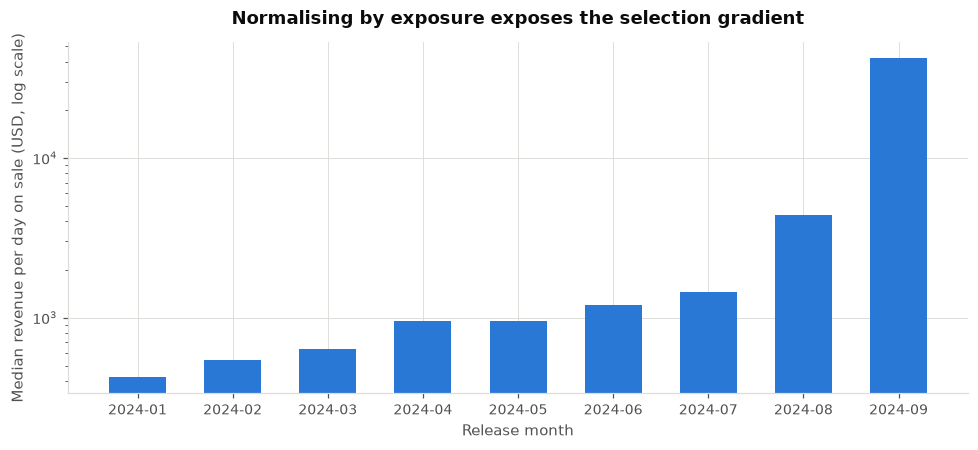

,Releases,Share of releases,Median revenue,Median review score
releaseWeekday,,,,
Monday,199,13.3,105087.0,85.0
Tuesday,247,16.5,173665.0,83.0
Wednesday,239,15.9,143115.0,85.0
Thursday,436,29.1,133000.0,86.0
Friday,272,18.1,72786.0,83.5
Saturday,57,3.8,52803.0,77.0
Sunday,50,3.3,67688.0,84.0


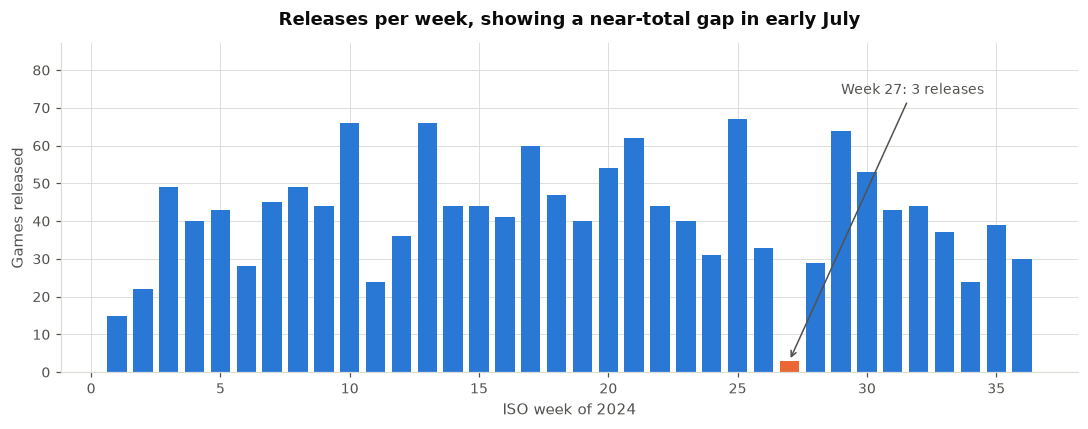

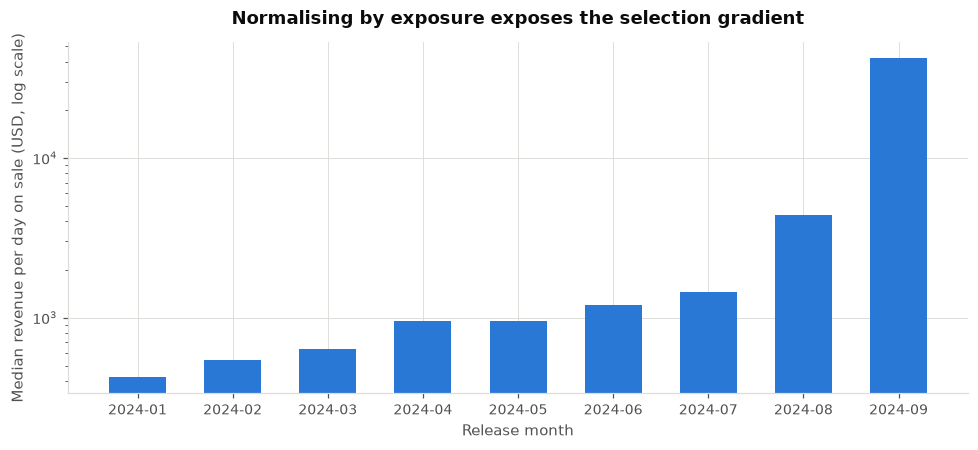

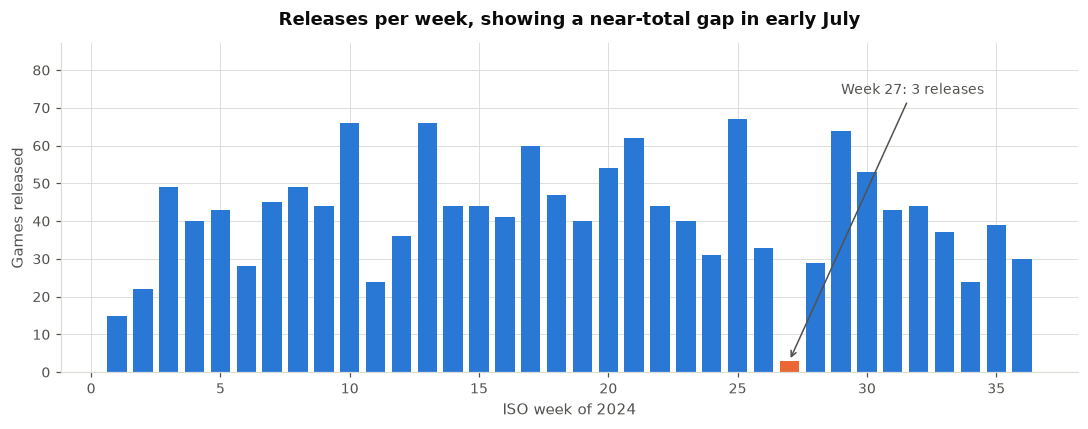

In [85]:
display(plot_revenue_per_day_trend(engineered_games))
display(summarise_release_timing(engineered_games))
display(plot_release_calendar(engineered_games))

### 9.2 Time dependence and links to outside knowledge

**Release timing follows a strong industry convention that is plainly visible in
the data.** Thursday alone carries **29.1%** of all releases, and Tuesday to
Friday together carry 79.6%. The weekend is nearly empty: Saturday and Sunday
hold 3.8% and 3.3% respectively.

This is not a property of games; it is a property of how the industry schedules.
A weekday release gets a full business week of press coverage and storefront
visibility, and it lets a studio staff its launch-day support. Weekend releases
also earn noticeably less — a median of $52,803 on Saturday against $173,665 on
Tuesday — though the causation is likely reversed: titles with real commercial
backing are the ones that get a prime slot, so the weekday gap reflects which
games are launched when, not the power of a day of the week.

**One week is almost entirely missing, and the gap lines up with an external
event.** ISO week 27 of 2024 — 1 to 7 July — contains **3 releases**, against a
typical 40 and a maximum of 67. Nothing in the dataset explains a drop of that
size.

The likely explanation is external. Steam runs a **Summer Sale** across late
June and early July, and studios have good reason to avoid launching into it:
during a platform-wide sale the storefront is dominated by discounted titles, a
new release cannot compete for visibility, and launching at full price beside
heavy discounts is commercially unattractive.

This is offered as a hypothesis rather than an established cause. The gap in
week 27 is measured directly from the data; the attribution to the Summer Sale
is an inference from domain knowledge, and confirming it would require the
storefront's promotional calendar, which this dataset does not contain.

This is a good illustration of the assignment's framing. The dataset records no
sales, no promotions and no storefront state — yet the shape of an external
commercial calendar is legible in it, provided one knows to look for it.

In [86]:
run_hypothesis_tests(engineered_games)

,Hypothesis,Test,p-value,Detail,Decision at alpha=0.010
0,AAA titles earn more than Indie titles,Mann-Whitney U (one-sided),1.33e-11,"medians $928,862 vs $90,773",Reject null
1,Weekend releases earn less than weekday releases,Mann-Whitney U (one-sided),1.3e-07,n = 107 weekend vs 1393 weekday,Reject null
2,Review score is associated with revenue,Spearman rank correlation,0.161,"rho = 0.0375 on n = 1,401",Fail to reject null
3,Free-to-play titles are rated differently from...,Mann-Whitney U (two-sided),2.72e-14,medians 74 vs 85,Reject null
4,Release weekday depends on publisher class,Chi-squared test of independence,8.46e-09,chi2 = 62.3 on 12 degrees of freedom,Reject null


### 9.3 Hypothesis testing

Five hypotheses are tested. Non-parametric tests are used throughout because
section 5 showed the numeric variables are heavily skewed with extreme tails,
which violates the normality assumption behind the t-test. Because five
hypotheses are tested on one dataset, a **Bonferroni correction** is applied and
the threshold becomes α = 0.01 rather than 0.05.

| Hypothesis | p-value | Decision |
|---|---|---|
| AAA titles earn more than Indie titles | 1.3 × 10⁻¹¹ | **Reject null** |
| Weekend releases earn less than weekday releases | 1.3 × 10⁻⁷ | **Reject null** |
| Review score is associated with revenue | 0.161 | **Fail to reject null** |
| Free-to-play titles are rated differently from paid | 2.7 × 10⁻¹⁴ | **Reject null** |
| Release weekday depends on publisher class | 8.5 × 10⁻⁹ | **Reject null** |

**The third test is the most valuable, precisely because it fails.** With
n = 1,401 the test has ample power to detect even a weak association, and it
still returns p = 0.161. The null result reported in sections 6 and 8 is
therefore not an artefact of a small sample — within this range-restricted
population, review score genuinely does not track revenue. A formal test
converts an observation into a defensible claim.

**The fourth result is new and slightly counter-intuitive.** Free-to-play titles
have a median review score of **74 against 85** for paid titles — they are rated
distinctly *worse*. Set beside the violin plot in section 6.3, which showed
free-to-play games have the **highest median playtime of any price band**, the
pair is genuinely interesting: these are the games people play the longest and
rate the lowest. A plausible reading is that monetisation mechanics attract
sustained engagement and simultaneous resentment, but this dataset cannot test
that — it would need review text, not review scores.

**A caution about all five.** Every test here is applied to the same selected
sample, so each conclusion is conditional on the selection described in section
8. "AAA titles earn more than Indie titles" is established *among the top 1,500
earners*, not across Steam.

### 9.4 Suggestions for further research

Ordered by how much each would improve on this analysis.

**1. Obtain the unselected population.** Every limitation in this notebook
descends from the top-1,500 cut. A full census of 2024 Steam releases would turn
every conditional statement here into an unconditional one, and would allow the
selection effect in section 6.3 to be measured rather than merely inferred.

**2. Recover review counts and audit the estimation model.** The file publishes
the model's output while withholding its principal input. With review counts,
the implied review-to-sales multiplier could be reconstructed and tested against
the handful of titles whose publishers have disclosed real sales figures. That
would convert "these are estimates of unknown accuracy" into a quantified error
bar.

**3. Collect repeated snapshots.** A single extract cannot separate a game's
earning *rate* from its time on sale. Monthly snapshots would give revenue
accumulation curves, allowing the exposure confound to be modelled directly
rather than engineered around.

**4. Add the missing fourth quarter, and prior years.** Q4 holds the holiday
sales and is absent entirely. Adding it, and then several years, would make it
possible to distinguish market structure from a single year's accidents.

**5. Add genre, tags and language data.** The most conspicuous omission for
analytical purposes. Genre would very likely explain much of the unexplained
variation in playtime and price, and language support would allow the
visibility bias against non-English markets, raised in section 8, to be tested.

**6. Model the realisation rate against discount history.** If `priceRealisation`
varies with observed discounting, it is a market measurement; if it is nearly
constant, it is a model parameter. Storefront price history would settle the
question section 9.1 had to leave open — and with it the gross-versus-net
ambiguity that limits every monetary claim in this notebook.